In [114]:
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm_notebook as tqdm
import numpy as np
import os
from torch import nn
from copy import copy

In [115]:
os.environ['CUDA_VISIBLE_DEVICES'] = '3'

In [116]:
cd ../src/BERT/

[Errno 2] No such file or directory: '../src/BERT/'
/home/rfit/Telescope_Array/phd_work/src/BERT


In [5]:
from pipline import PiplineMask
config = 'config.yaml'
pipline = PiplineMask(config, need_train_DS=False)
pipline.model.load('/home/rfit/Telescope_Array/phd_work/Models/BERT/BERT_8l_0.5/last')

Using device: cuda


2025-07-26 11:37:58.602358: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753519078.616108   39820 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753519078.620265   39820 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753519078.630861   39820 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753519078.630881   39820 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753519078.630883   39820 computation_placer.cc:177] computation placer alr

['pipline.py', '__pycache__', 'check.py', 'model.py', 'loss.py', 'config.yaml']
Saving Path: /home/rfit/Telescope_Array/phd_work/Models/BERT/BERT_test
6 64 16 6


In [6]:
def random_mask_index(x: torch.Tensor, probability: float, mask_v: float = -10) -> torch.Tensor:
    # рызыгрывать вероятности а не индексы. 
    device = x.device

    token_mask = (x[:,:,0:1] != mask_v).to(device)  # [batch, maxlen]
    token_mask[:, 0] = False  # исключаем первый токен

    index = torch.sum(token_mask, dim=1)[:,0] # one dim -> batch
    token_mask[torch.arange(index.size(0)), index] = False
    
    probability_tensor = torch.rand_like(x[:,:,0:1]) # batch, len, 1
    probability_tensor = probability_tensor*token_mask # zero in supportive tokens
    token_mask = torch.where(probability_tensor>(1-probability), 1, 0).to(device)
    # to shape -> batch, len, 6
    token_mask = torch.repeat_interleave(token_mask, 6, dim=2).to(device).to(torch.bool)
    return token_mask, index

In [6]:
min_sig_pr = 0
for x,_,_ in tqdm(pipline.val_loaders[0]):
    min_sig_pr += len(x)
print(min_sig_pr)
min_sig = 0
for x,_,_ in tqdm(pipline.val_loaders[1]):
    min_sig += len(x)
print(min_sig)

/tmp/ipykernel_44969/2953808764.py:2: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for x,_,_ in tqdm(pipline.val_loaders[0]):


  0%|          | 0/866 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.data[st:fn]), torch.tensor(mc_params[1]), torch.tensor(params_CR)


KeyboardInterrupt: 

In [1]:
def sort_tensor(x):
    # Извлекаем 0-ю и 1-ю колонки
    col0 = x[..., 0]
    col1 = x[..., 1]
    
    # Получаем индексы сортировки по col0, а затем по col1
    sorted_indices = torch.argsort(col0, stable=True)  # Сначала сортируем по col0
    sorted_indices = sorted_indices[torch.argsort(col1[sorted_indices], stable=True)]  # Затем по col1

    # Возвращаем отсортированный тензор
    return x[sorted_indices]

In [2]:
sort_tensor(x[0])[:,0]

NameError: name 'x' is not defined

In [1]:
x[1,1:10,0]-x[1,1:10,0].min()

NameError: name 'x' is not defined

In [15]:
for i in range(len(x)):
    print(torch.abs(x[i,1:10,1]-x[i,1:10,1].min()-0.8).min()+0.8)

tensor(0.8027)
tensor(0.8036)
tensor(0.8002)
tensor(0.8009)
tensor(0.8009)
tensor(0.8014)
tensor(0.8001)
tensor(0.8005)
tensor(1.)
tensor(0.8096)
tensor(0.8005)
tensor(0.8014)
tensor(0.8001)
tensor(1.6000)
tensor(0.8025)
tensor(1.6000)
tensor(0.8025)
tensor(0.8006)
tensor(0.8001)
tensor(1.5998)
tensor(0.8149)
tensor(0.8271)
tensor(0.8280)
tensor(0.8658)
tensor(0.8007)
tensor(0.8394)
tensor(0.8159)
tensor(0.8085)
tensor(0.8043)
tensor(0.8472)
tensor(0.8096)
tensor(0.8020)
tensor(1.)
tensor(0.8011)
tensor(0.8001)
tensor(0.8295)
tensor(0.8006)
tensor(0.9915)
tensor(0.8001)
tensor(1.5996)
tensor(0.8490)
tensor(0.8614)
tensor(1.6000)
tensor(0.8001)
tensor(0.8015)
tensor(0.8001)
tensor(0.8007)
tensor(0.8018)
tensor(0.8004)
tensor(0.8287)
tensor(1.)
tensor(0.8033)
tensor(0.8031)
tensor(0.8005)
tensor(0.8019)
tensor(0.8036)
tensor(0.8006)
tensor(0.8015)
tensor(0.8003)
tensor(1.6000)
tensor(0.8029)
tensor(0.8014)
tensor(0.8006)
tensor(0.8014)
tensor(0.8025)
tensor(0.8001)
tensor(0.8004)
tensor(

In [9]:
1-min_sig_pr/(min_sig_pr+min_sig), 1-min_sig/(min_sig_pr+min_sig)

(0.3186702476079202, 0.6813297523920798)

In [118]:
min_sig = 0
# for x,_,_ in tqdm(pipline.val_loaders[0]):
#     min_sig = min(min_sig, x[:,:,3:4].min())
for x,_,_ in tqdm(pipline.val_loaders[1]):
    min_sig = min(min_sig, x[:,:,3:4].min())
min_sig

/tmp/ipykernel_39820/1176098700.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for x,_,_ in tqdm(pipline.val_loaders[1]):


  0%|          | 0/405 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)


KeyboardInterrupt: 

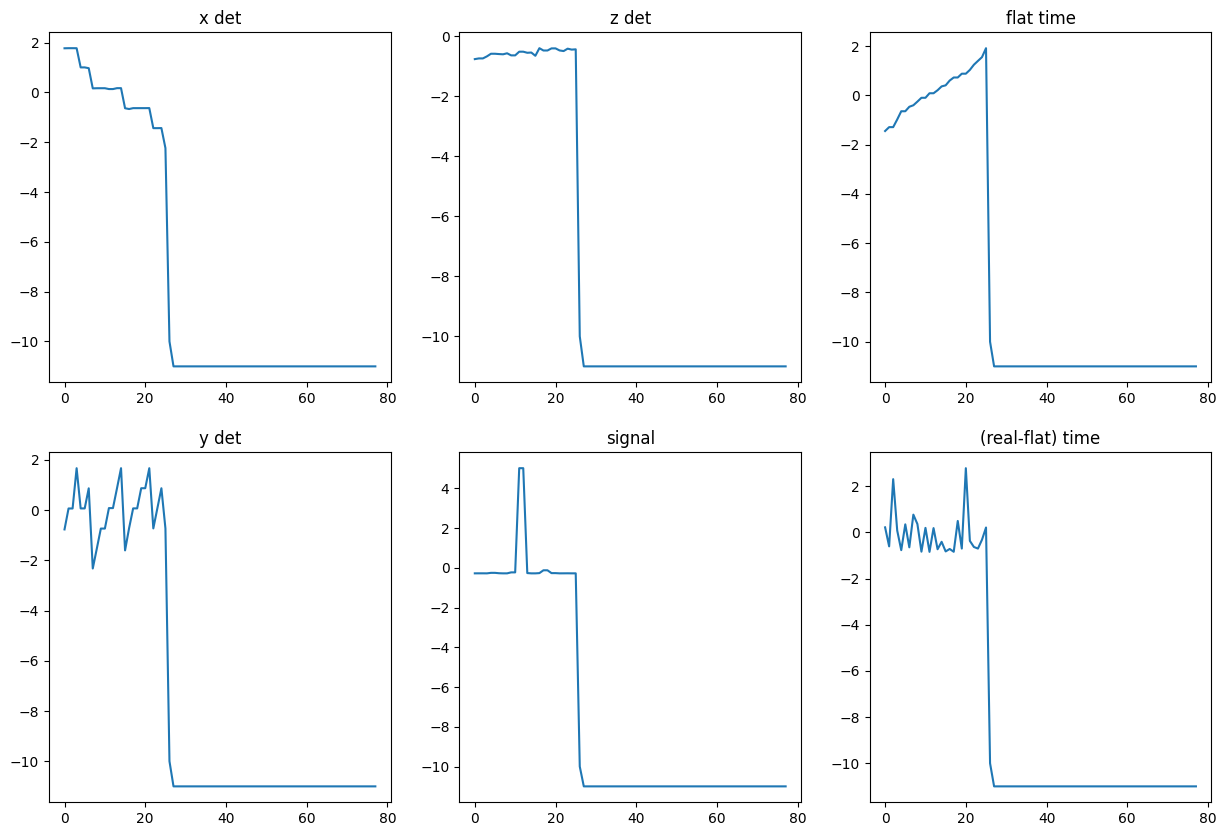

In [10]:
x[0].shape
def show(x,stop=100, n=0):
    f,ax = plt.subplots(2,3,figsize=(15,10))
    names = ['x det','y det','z det','signal', 'flat time', '(real-flat) time']
    for i in range(6):
        ax[i%2][i//2].plot(x[n,1:stop,i])
        ax[i%2][i//2].set_title(names[i])
show(x,stop=100)

In [119]:
num_ev = 0
# x[:,:,3:] = x[:,:,3:]/10
# x[:,:,:3] = x[:,:,:3] * 2
masking = random_mask_index(x[num_ev:num_ev+1], 1.0, -11)[0]
recon = pipline.model(x[num_ev:num_ev+1].to('cuda'), masking.to('cuda'))
print(recon.shape)
masking[:,:,0]

torch.Size([1, 56, 6])


tensor([[False,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False]])

In [142]:
num_ev = 0
res = []
masking = random_mask_index(x[num_ev:num_ev+1], 1.0, -11)[0]
for i in range(1,10):
    x_data = x[num_ev:num_ev+1, :-i]
    masking_slice= masking[:, :-i]
    recon = pipline.model(x_data.to('cuda'), masking_slice.to('cuda'))
    res.append(recon)

In [143]:
res[0].shape

torch.Size([1, 55, 6])

In [144]:
res[1].shape

torch.Size([1, 54, 6])

In [145]:
lenght= masking[0,:,-1].sum()
for i in range(9):
    res[i] = res[i][:,1:lenght+1]
    print(res[i].shape)

torch.Size([1, 15, 6])
torch.Size([1, 15, 6])
torch.Size([1, 15, 6])
torch.Size([1, 15, 6])
torch.Size([1, 15, 6])
torch.Size([1, 15, 6])
torch.Size([1, 15, 6])
torch.Size([1, 15, 6])
torch.Size([1, 15, 6])


In [146]:
res[0]-res[5]

tensor([[[0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.]]], device='cuda:0', grad_fn=<SubBackward0>)

NameError: name 'copy' is not defined

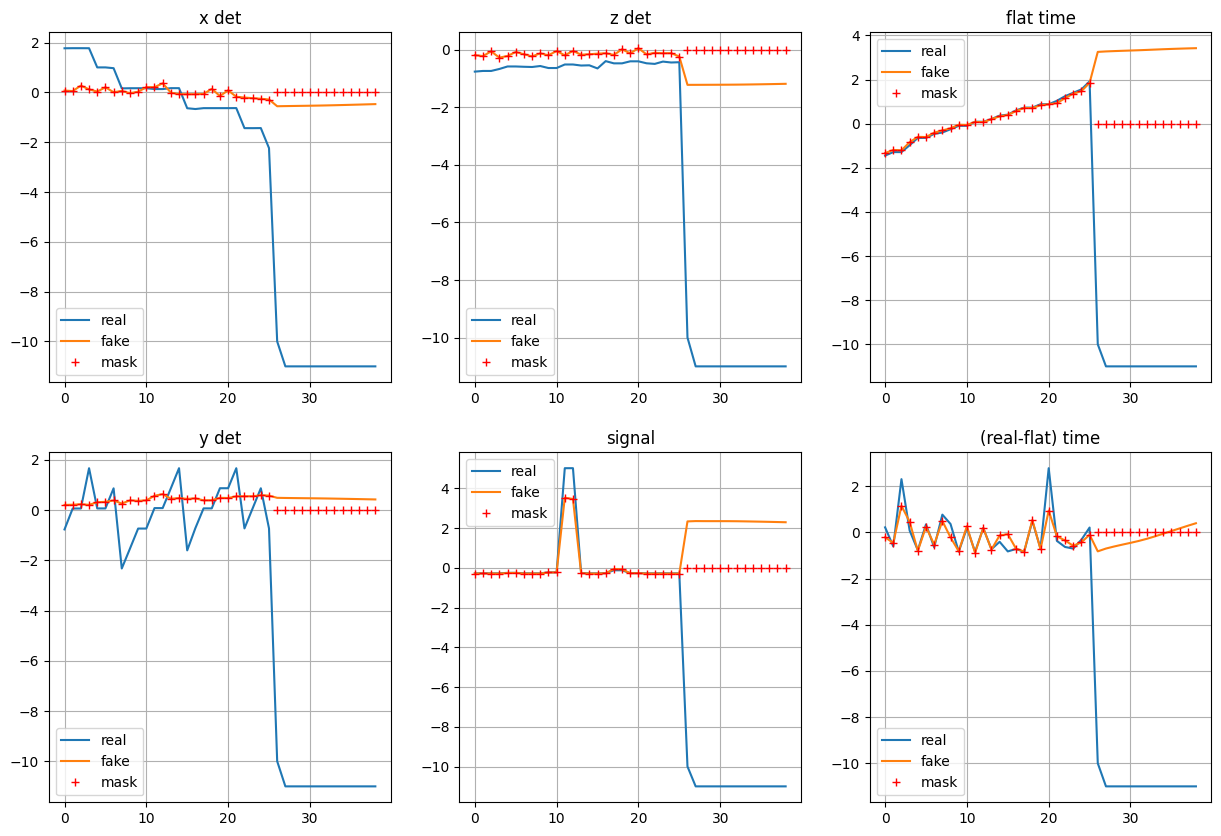

In [12]:
stop = 40
f,ax = plt.subplots(2,3,figsize=(15,10))
names = ['x det','y det','z det','signal', 'flat time', '(real-flat) time']
for i in range(6):
    ax[i%2][i//2].plot(x[num_ev,1:stop,i], label = 'real')
    # ax[i%2][i//2].set_title(names[i])

    ax[i%2][i//2].plot(recon.cpu().detach().numpy()[0,1:stop,i], label = 'fake')
    # ax[i%2][i//2].set_title(names[i])

    ax[i%2][i//2].plot(masking.cpu().detach().numpy()[0,1:stop,i]*recon.cpu().detach().numpy()[0,1:stop,i],
                        'r+',  label = 'mask')
    
    ax[i%2][i//2].legend()
    ax[i%2][i//2].grid()
    ax[i%2][i//2].set_title(names[i])
recon1 = copy(recon)

In [148]:
masking[:,:,0].shape, x[0:1,:,3].shape
scalar = (10-1)*masking[:,:,0] +1 
scalar*scalar

tensor([[  1, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
         100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,
         100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
           1,   1,   1]])

In [149]:
num_ev = 0
# x[:,:,3:] = x[:,:,3:]/10
# x[:,:,:3] = x[:,:,:3] * 2
masking = random_mask_index(x[num_ev:num_ev+1], 1.0, -11)[0]
scalar = (10-1)*masking[:,:,0] +1 
x2 = copy(x)
x2[:,:,3] = x2[:,:,3]*scalar
recon = pipline.model(x2[num_ev:num_ev+1].to('cuda'), masking.to('cuda'))
print(recon.shape)
masking[:,:,0]

x tensor([[[ 0.0000e+00,  0.0000e+00,  0.0000e+00, -2.7791e-01, -8.7980e+00,
           1.5595e+01],
         [-1.1741e+00, -1.9246e+00, -1.1985e+00, -2.7268e+00, -9.5647e-01,
           1.5466e+00],
         [-1.9744e+00, -1.0916e+00, -1.1444e+00, -2.7294e+00, -7.5123e-01,
           1.4357e+00],
         [-1.1721e+00, -1.0114e+00, -1.1279e+00, -2.6770e+00, -5.3510e-01,
          -4.1094e-01],
         [-1.1721e+00, -1.0114e+00, -1.1279e+00, -2.6770e+00, -5.3510e-01,
           9.6348e-01],
         [-4.5627e-01, -1.1534e+00, -1.1578e+00, -2.5293e+00, -4.4001e-01,
          -6.6010e-01],
         [-4.5627e-01, -1.1534e+00, -1.1578e+00, -2.5293e+00, -4.4001e-01,
           3.6870e-01],
         [-4.5627e-01, -1.1534e+00, -1.1578e+00, -2.5293e+00, -4.4001e-01,
           1.4136e+00],
         [ 4.2973e-01, -1.0959e+00, -1.1642e+00, -2.4966e+00, -2.1524e-01,
          -7.0310e-01],
         [ 4.2973e-01, -1.0959e+00, -1.1642e+00, -2.4966e+00, -2.1524e-01,
           3.2570e-01],
        

tensor([[False,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
          True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False]])

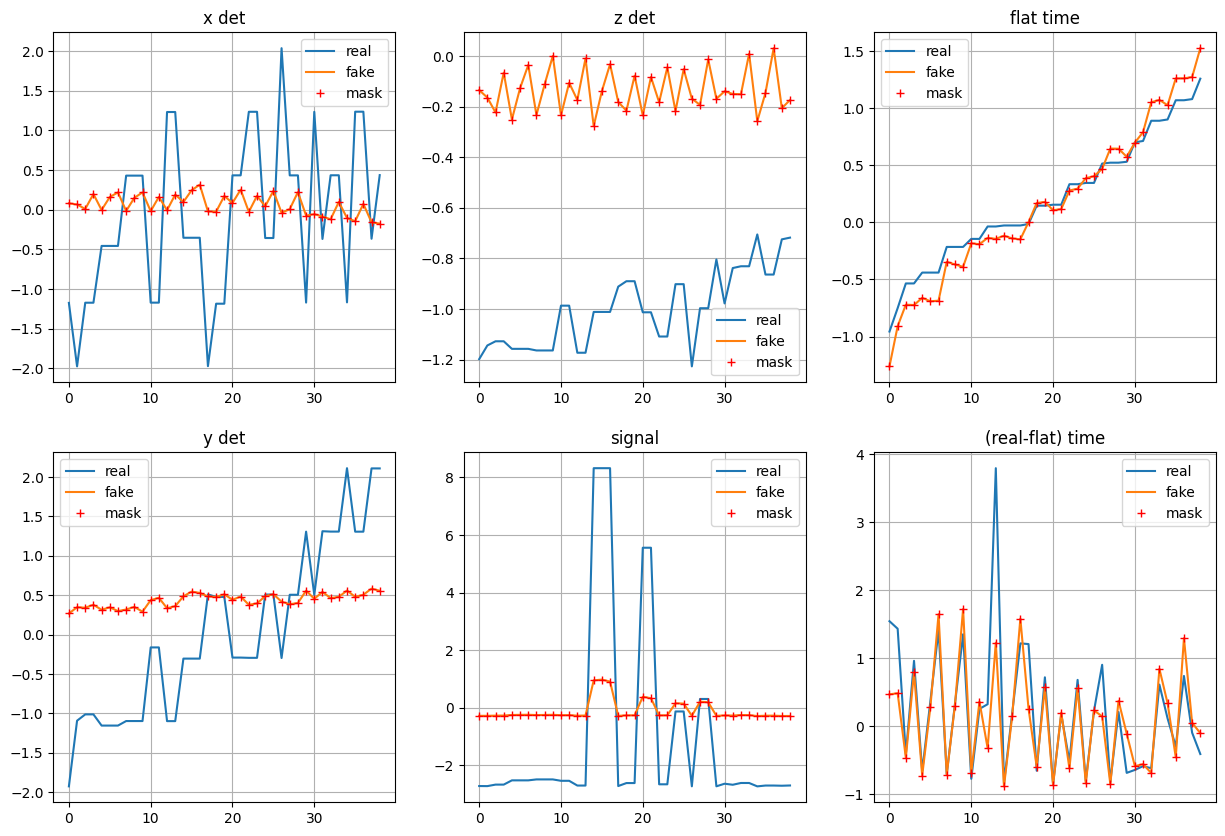

In [150]:
stop = 40
f,ax = plt.subplots(2,3,figsize=(15,10))
names = ['x det','y det','z det','signal', 'flat time', '(real-flat) time']
for i in range(6):
    ax[i%2][i//2].plot(x[num_ev,1:stop,i], label = 'real')
    # ax[i%2][i//2].set_title(names[i])

    ax[i%2][i//2].plot(recon.cpu().detach().numpy()[0,1:stop,i], label = 'fake')
    # ax[i%2][i//2].set_title(names[i])

    ax[i%2][i//2].plot(masking.cpu().detach().numpy()[0,1:stop,i]*recon.cpu().detach().numpy()[0,1:stop,i],
                        'r+',  label = 'mask')
    
    ax[i%2][i//2].legend()
    ax[i%2][i//2].grid()
    ax[i%2][i//2].set_title(names[i])
recon2 = copy(recon)

In [136]:
from copy import copy
recon2 = copy(recon)

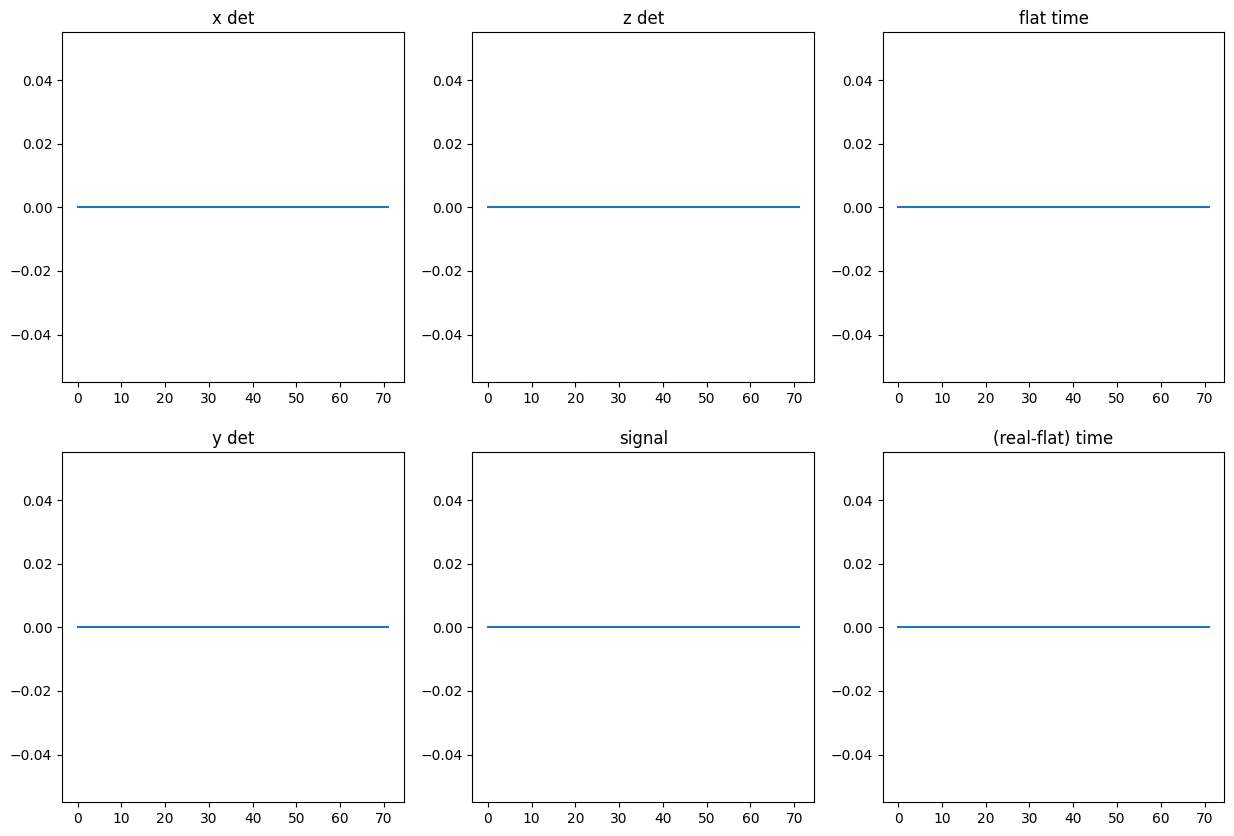

In [151]:
show(recon2.cpu().detach().numpy()- recon1.cpu().detach().numpy(),100)

In [103]:
class MaskLoss():
    def __init__(self, reduction = 'mean', min_sig=0):
        # super().__init__()
        self.LossMSE = nn.MSELoss(reduction='none') 
        self.min_sig = min_sig

    def __call__(self, recon_x, x, mask_tensor):
        none_loss = self.LossMSE(recon_x, x)
        none_loss_mask = none_loss*mask_tensor
        mean_loss =  torch.sum(none_loss_mask)/(torch.sum(mask_tensor) + 1e-6)
        return mean_loss
    def by_ev_return(self, recon_x, x, mask_tensor):
        weight = torch.tensor([0,0,0,1,1,0]).unsqueeze(0).unsqueeze(0).to(recon_x.device)
        none_loss = self.LossMSE(recon_x, x)
        none_loss_mask = none_loss*mask_tensor*weight
        none_loss_mask = torch.sum(none_loss_mask, dim = 2)
        none_loss_mask = torch.sum(none_loss_mask, dim = 1)
        mask_tensor = torch.sum(mask_tensor, dim = 2)
        mask_tensor = torch.sum(mask_tensor, dim = 1)
        mean_loss =  none_loss_mask/(mask_tensor+ 1e-6)
        return mean_loss
    def by_chanal(self, recon_x, x, mask_tensor):
        none_loss = self.LossMSE(recon_x, x)
        none_loss_mask = none_loss*mask_tensor
        # none_loss_mask = torch.sum(none_loss_mask, dim = 2)
        none_loss_mask = torch.sum(none_loss_mask, dim = 1)
        # mask_tensor = torch.sum(mask_tensor, dim = 2)
        mask_tensor = torch.sum(mask_tensor, dim = 1)
        mean_loss =  none_loss_mask/(mask_tensor+ 1e-6) # batch, 6
        # mean_loss = mean_loss.mean()
        return mean_loss
    def div_signal(self, recon_x, x, mask_tensor):
        none_loss = self.LossMSE(recon_x, x)
        none_loss_mask = none_loss*mask_tensor*(x[:,:,3:4]-self.min_sig)
        none_loss_mask = torch.sum(none_loss_mask, dim = 2)
        none_loss_mask = torch.sum(none_loss_mask, dim = 1)
        mask_tensor = torch.sum(mask_tensor, dim = 2)
        mask_tensor = torch.sum(mask_tensor, dim = 1)
        mean_loss =  none_loss_mask/(mask_tensor+ 1e-6)
        return mean_loss
    def by_signal(self, recon_x, x, mask_tensor):
        none_loss = self.LossMSE(recon_x, x)
        none_loss_mask = none_loss*mask_tensor*(x[:,:,3:4]-self.min_sig)
        none_loss_mask = torch.sum(none_loss_mask, dim = 2)
        none_loss_mask = torch.sum(none_loss_mask, dim = 1)
        mask_tensor = torch.sum(mask_tensor, dim = 2)
        mask_tensor = torch.sum(mask_tensor, dim = 1)
        mean_loss =  none_loss_mask/(mask_tensor+ 1e-6)
        return mean_loss
    def get_channel3_loss_and_values(self, recon_x, x, mask_tensor):
        # Выделяем 4-й канал (индекс 3)
        x_ch3 = x[..., 3:4]   # [batch, seq_len, 1]
        # recon_x_ch3 = recon_x[..., 3:4]
        
        # Вычисляем MSE только для 4-го канала
        ch3_loss = self.LossMSE(x, recon_x)  # [batch, seq_len, 6]
        ch3_loss = torch.mean(ch3_loss, dim=-1).unsqueeze(-1)
        print(sum(mask_tensor))
        # Создаем маску для 4-го канала (предполагаем, что маска одинакова для всех каналов)
        mask = mask_tensor[..., 0:1].bool()  # [batch, seq_len, 1]
        print(sum(mask))
        # Применяем маску к ошибкам и значениям x
        errors = ch3_loss[mask]      # вектор ошибок в точках маски
        values = x_ch3[mask]         # вектор значений x[...,3] в точках маски
        print(errors.shape, values.shape)
        return torch.flatten(errors), torch.flatten(values)
Loss = MaskLoss(min_sig = 0)

In [104]:
device ='cuda:0'
def validation_step(epoch: int, val_loader, particle=None, probability = float(pipline.config['probability'])):
    particle = '' if particle is None else particle
    loss_mean = torch.zeros(0,)
    index_all = torch.zeros(0,)
    pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")
    num_examples = 0
    for x, part, params_CR in pbar_val:  # x should be a batch of sequences with padding
        num_examples += x.size(0)
        with torch.no_grad():
            x_mask, index = random_mask_index(x, probability=probability, mask_v = pipline.config['padding_value'])
            x_mask = x_mask.to(device)
            index_all = torch.concat((index_all, index))
            x = x.to(device)
            part = torch.where(part == 1, 0, 1).to(device) # 0- photon, 1- proton
            params_CR = params_CR.to(device)
            recon_x = pipline.model(x, x_mask)
            loss = Loss.by_ev_return(recon_x, x, x_mask)
            pbar_val.set_description(f"VAL {particle} Loss:")
            loss_mean = torch.concat((loss_mean, loss.to('cpu')))

            # return signal
            # sigqnal = x[:,:,3*4]*x_mask[:,:,3:4]
            
    return loss_mean, index_all

In [10]:
def validation_step_by_signal(epoch: int, val_loader, particle=None, probability = float(pipline.config['probability'])):
    particle = '' if particle is None else particle
    loss_mean = torch.zeros(0,)
    signal_mean = torch.zeros(0,)
    index_all = torch.zeros(0,)
    pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")
    num_examples = 0
    for x, part, params_CR in pbar_val:  # x should be a batch of sequences with padding
        num_examples += x.size(0)
        with torch.no_grad():
            x_mask, index = random_mask_index(x, probability=probability, mask_v = pipline.config['padding_value'])
            x_mask = x_mask.to(device)
            index_all = torch.concat((index_all, index))
            x = x.to(device)
            part = torch.where(part == 1, 0, 1).to(device) # 0- photon, 1- proton
            params_CR = params_CR.to(device)
            recon_x = pipline.model(x, x_mask)
            loss, signal = Loss.get_channel3_loss_and_values(recon_x, x, x_mask)
            pbar_val.set_description(f"VAL {particle} Loss:")
            loss_mean = torch.concat((loss_mean, loss.to('cpu')))
            signal_mean = torch.concat((signal_mean, signal.to('cpu')))
            print(loss.shape, signal.shape)
            # return signal
            # sigqnal = x[:,:,3*4]*x_mask[:,:,3:4]
    return loss_mean, index_all, signal_mean
            

In [110]:
def get_lenght(x):
    return len(x) - (x[:,0]==-11).sum()-1-1
def double_detector(x):
    lenght = get_lenght(x)
    coords = x[1:lenght+1,:4]
    unique_coords, inverse_indices, counts = torch.unique(coords, return_inverse=True, return_counts=True, dim=0)
    duplicate_mask = counts > 1
    duplicate_coords = unique_coords[duplicate_mask]

    # Optional: get indices of all duplicates in original tensor
    duplicate_indices = []
    for coord in duplicate_coords:
        matches = (coords == coord).all(dim=1)
        indices = torch.nonzero(matches).flatten().tolist()
        if len(indices) > 1:
            duplicate_indices.append(indices)

    return duplicate_indices
a=torch.tensor([[1,2,3,4],
               [1,2,3,4],
               [1,2,3,4],
               [0,3,0,0,]])
print(double_detector(a))
    

[[0, 1]]


In [111]:
def remove_events_with_duplicates(x):
    """
    Applies `double_detector` to each sample in x (shape: [N, 50, 6]).
    Removes samples where duplicates are detected.
    """
    valid_samples = []
    for i in range(x.size(0)):
        sample = x[i]
        print(double_detector(sample))
        if double_detector(sample) == []:
            valid_samples.append(sample)

    # Stack valid samples back into a tensor
    return torch.stack(valid_samples, dim=0)
print(x.shape)
res = remove_events_with_duplicates(x)
print(res.shape)

torch.Size([900, 58, 6])
[[8, 9, 10], [4, 5], [16, 17], [11, 12], [6, 7], [13, 14], [1, 2]]
[[7, 8], [13, 14], [15, 16], [1, 2], [9, 10], [17, 18], [3, 4, 5], [11, 12]]
[[12, 13], [20, 21], [25, 26], [8, 9], [14, 15, 16, 17], [1, 2, 3], [4, 5, 6], [10, 11]]
[[3, 4]]
[[25, 26], [19, 20], [21, 22], [17, 18], [13, 14], [15, 16], [4, 5], [6, 7], [8, 9], [10, 11], [0, 1]]
[]
[[26, 27], [29, 30], [13, 14], [21, 22], [4, 5], [18, 19, 20], [9, 10, 11], [23, 24, 25], [15, 16, 17], [6, 7, 8]]
[[5, 6], [9, 10], [1, 2], [3, 4]]
[[3, 4], [1, 2], [7, 8], [5, 6]]
[[10, 11], [12, 13], [6, 7], [4, 5], [8, 9], [1, 2]]
[]
[[12, 13], [4, 5], [8, 9], [10, 11], [6, 7], [2, 3], [0, 1]]
[[9, 10], [7, 8], [11, 12], [4, 5]]
[[4, 5], [15, 16], [6, 7], [8, 9, 10], [0, 1], [11, 12], [2, 3], [13, 14]]
[]
[[4, 5], [2, 3]]
[[4, 5], [0, 1], [6, 7, 8]]
[[4, 5], [1, 2]]
[[3, 4], [1, 2]]
[[1, 2], [5, 6], [3, 4]]
[[8, 9, 10], [2, 3], [4, 5, 6]]
[[0, 1], [6, 7], [2, 3]]
[]
[[1, 2], [7, 8]]
[[12, 13, 14], [1, 2], [5, 6], [3

In [113]:
x[1]

tensor([[  0.0000,   0.0000,   0.0000,  -0.2779,  -8.7980,  15.5954],
        [ -1.1343,   1.5450,  -1.1077,  -0.2722,  -1.2292,  -0.3872],
        [ -0.3319,   1.5440,  -1.2062,  -0.2690,  -1.1416,  -0.3446],
        [ -0.3319,   1.5440,  -1.2062,  -0.2690,  -1.1416,   0.6922],
        [  0.4683,   1.5460,  -1.2698,  -0.2675,  -1.0574,  -0.5058],
        [  0.4683,   1.5460,  -1.2698,  -0.2675,  -1.0574,   0.5230],
        [  0.4683,   1.5460,  -1.2698,  -0.2675,  -1.0574,   2.7012],
        [ -1.9353,   0.7463,  -1.0881,  -0.2737,  -0.6416,  -0.1887],
        [ -1.1713,   0.7532,  -1.1061,  -0.2687,  -0.5663,  -0.3052],
        [ -1.1713,   0.7532,  -1.1061,  -0.2687,  -0.5663,   1.2380],
        [ -0.2938,   0.7441,  -1.1553,  -0.1874,  -0.4651,  -0.8289],
        [ -0.2938,   0.7441,  -1.1553,  -0.1874,  -0.4651,   0.1999],
        [  0.4714,   0.7409,  -1.2999,  -0.2244,  -0.3789,  -0.9213],
        [  0.4714,   0.7409,  -1.2999,  -0.2244,  -0.3789,   0.1075],
        [ -1.1362,  

In [62]:
def validation_step_chanal(epoch: int, val_loader, particle=None, probability = float(pipline.config['probability'])):
    particle = '' if particle is None else particle
    loss_mean = torch.zeros(0,6)
    index_all = torch.zeros(0,)
    pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")
    num_examples = 0
    for x, part, params_CR in pbar_val:  # x should be a batch of sequences with padding
        num_examples += x.size(0)
        with torch.no_grad():
            x_mask, index = random_mask_index(x, probability=probability, mask_v = pipline.config['padding_value'])
            x_mask = x_mask.to(device)
            index_all = torch.concat((index_all, index))
            x = x.to(device)
            part = torch.where(part == 1, 0, 1).to(device) # 0- photon, 1- proton
            params_CR = params_CR.to(device)
            recon_x = pipline.model(x, x_mask)
            loss = Loss.by_chanal(recon_x, x, x_mask)
            pbar_val.set_description(f"VAL {particle} Loss:")
            loss_mean = torch.concat((loss_mean, loss.to('cpu')),dim=0)

            # return signal
            # sigqnal = x[:,:,3*4]*x_mask[:,:,3:4]
            
    return loss_mean, index_all

In [72]:
res = validation_step(-1, pipline.val_loaders[1], '_ph', probability=0.1)


/tmp/ipykernel_39820/951860104.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

In [73]:
res2 = validation_step(-1, pipline.val_loaders[1], '_ph', probability=0.5)

/tmp/ipykernel_39820/951860104.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

In [74]:
res_ch = validation_step_chanal(-1, pipline.val_loaders[1], '_ph', probability=0.5)
res_ch_pr = validation_step_chanal(-1, pipline.val_loaders[0], 'pr', probability=0.5)

/tmp/ipykernel_39820/1983431656.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

part: pr chanal: 3mean:0.014162007719278336 std:0.10751184821128845
part: ph chanal: 3mean:0.047227680683135986 std:0.3192119002342224
part: pr chanal: 4mean:0.0005968118202872574 std:0.0033613971900194883
part: ph chanal: 4mean:0.0007446098024956882 std:0.003908317536115646
part: pr chanal: 5mean:0.3048558831214905 std:1.3492761850357056
part: ph chanal: 5mean:0.31032973527908325 std:1.452174425125122


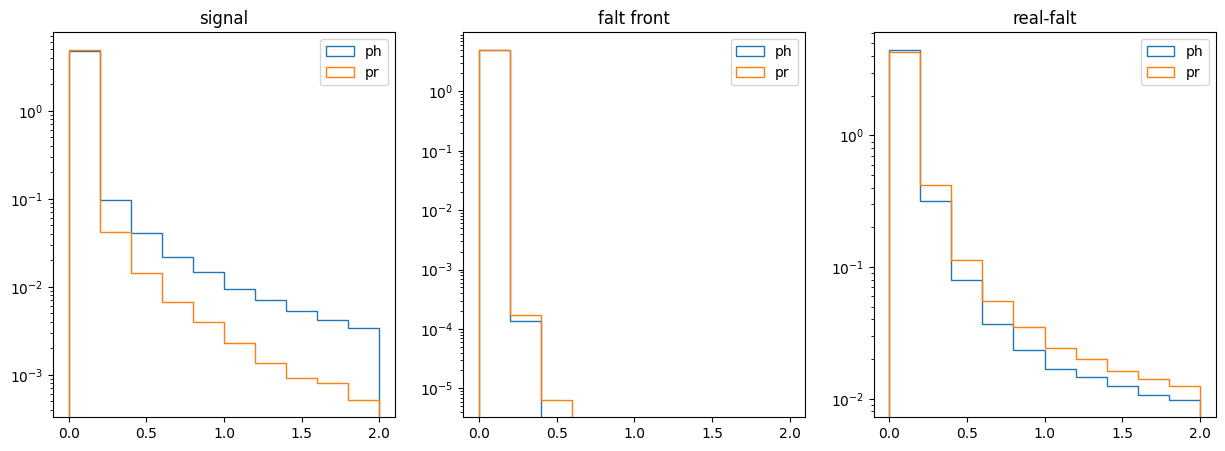

In [78]:
loss_ch_ph = res_ch[0]
loss_ch_pr = res_ch_pr[0]
diapazon = np.array([0, 2])
f, axs = plt.subplots(1,3, figsize=(15,5))
names = ['signal', 'falt front', 'real-falt']
for i in range(3,6):
    print(f'part: pr chanal: {i}mean:{loss_ch_pr[:,i].mean()} std:{loss_ch_pr[:,i].std()}')
    print(f'part: ph chanal: {i}mean:{loss_ch_ph[:,i].mean()} std:{loss_ch_ph[:,i].std()}')
    axs[i-3].hist(loss_ch_ph[:,i], log=True,range=diapazon, histtype='step', label='ph', density=True)
    axs[i-3].hist(loss_ch_pr[:,i], log=True,range=diapazon, histtype='step', label='pr', density=True)
    axs[i-3].legend()
    axs[i-3].set_title(names[i-3])


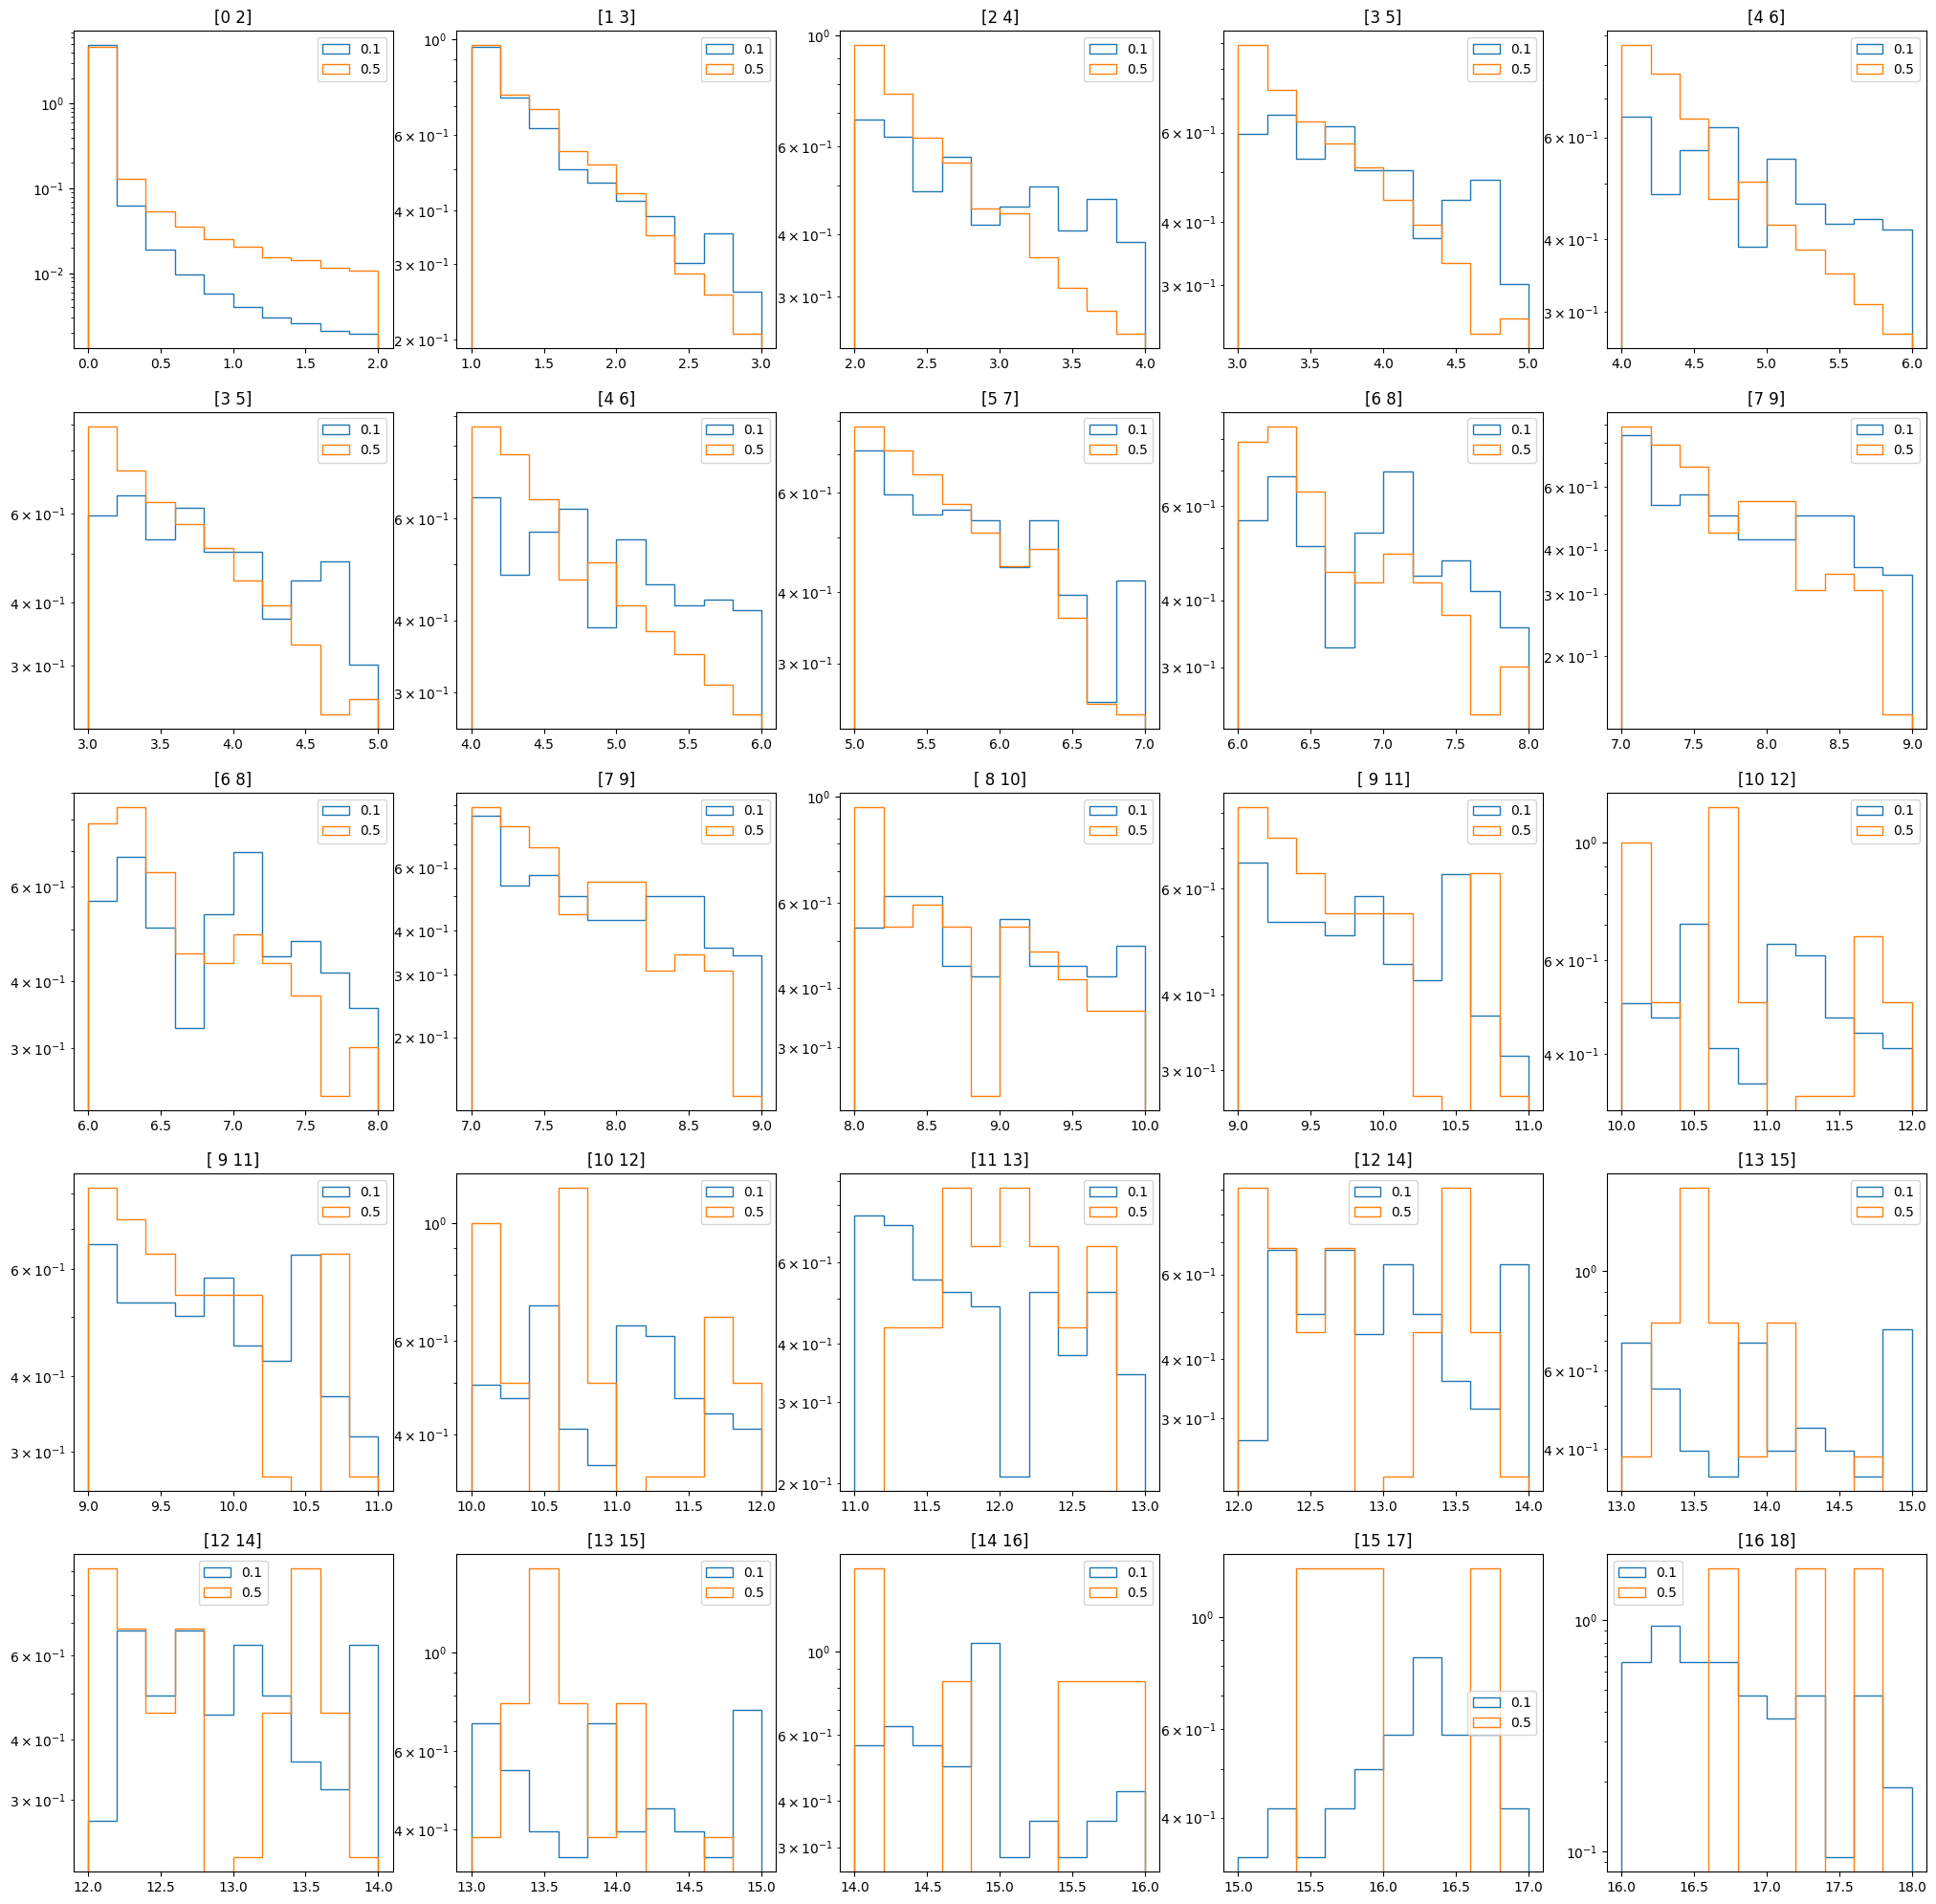

In [76]:
def subplot(res,res2, ncol=3, nrow=3):
    f, axs = plt.subplots(nrow, ncol, figsize=(5*ncol, 5*nrow) )
    for r in range(nrow):
        for c in range(ncol):
            diapazon = np.array([0, 2]) + 3*r+c
            axs[r][c].hist(res[0], label='0.1', range=diapazon, histtype='step', log=True, density=True)
            axs[r][c].hist(res2[0], label='0.5', range=diapazon, histtype='step', log=True, density=True)
            axs[r][c].set_title(str(diapazon))
            axs[r][c].legend()
subplot(res,res2, ncol=5, nrow=5)

In [9]:
def validation_step_event_return(epoch: int, val_loader, particle=None, probability = float(pipline.config['probability'])):
    particle = '' if particle is None else particle
    loss_mean = torch.zeros(0,)
    index_all = torch.zeros(0,)
    pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")
    recon_list = []
    data_list = []
    mask_list = []
    num_examples = 0
    for x, part, params_CR in pbar_val:  # x should be a batch of sequences with padding
        num_examples += x.size(0)
        with torch.no_grad():
            x_mask, index = random_mask_index(x, probability=probability, mask_v = pipline.config['padding_value'])
            x_mask = x_mask.to(device)
            index_all = torch.concat((index_all, index))
            x = x.to(device)
            part = torch.where(part == 1, 0, 1).to(device) # 0- photon, 1- proton
            params_CR = params_CR.to(device)
            recon_x = pipline.model(x, x_mask)
            loss = Loss.by_ev_return(recon_x, x, x_mask)
            pbar_val.set_description(f"VAL {particle} Loss:")
            loss_mean = torch.concat((loss_mean, loss.to('cpu')))

            recon_list += [i.to('cpu') for i in recon_x]
            data_list += [i.to('cpu') for i in x]
            mask_list += [i.to('cpu') for i in x_mask]
            
    return loss_mean, index_all, data_list, recon_list, mask_list

In [10]:
events_01 = validation_step_event_return(-1, pipline.val_loaders[1], '_ph', probability=0.1)
events_05 = validation_step_event_return(-1, pipline.val_loaders[1], '_ph', probability=0.5)

/tmp/ipykernel_39820/1738989306.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

In [11]:
events_01[0].shape, len(events_01[2])

(torch.Size([364387]), 364387)

In [45]:
def get_lenght(x):
    return len(x) - (x[:,0]==-11).sum()-1-1
def get_most_loss(res, num, pr:str):
    f, axs = plt.subplots(num, 3, figsize = (7*3, 7*num))
    loss_mean, index_all, data_list, recon_list, mask_list = res
    sorted_x, indices = torch.sort(loss_mean)
    for i, ind in enumerate(indices[-num:]):
        names = ['signal', 'flat time', '(real-flat) time']
        ax = axs[i]
        x = data_list[ind]
        recon = recon_list[ind]
        mask = mask_list[ind]
        stop = get_lenght(x)
        for j in range(3,6):
            ax[j-3].plot(x[1:stop+1,j], label = 'real')
            ax[j-3].plot(recon[1:stop+1,j], label = 'fake')
            ax[j-3].plot(recon[1:stop+1,j]*mask[1:stop+1,j], '--', label = 'fake_mask')
            ax[j-3].set_title(loss_mean[ind])
            ax[j-3].legend()
    f.suptitle(f'probability {pr} highest loss', fontweight='bold')


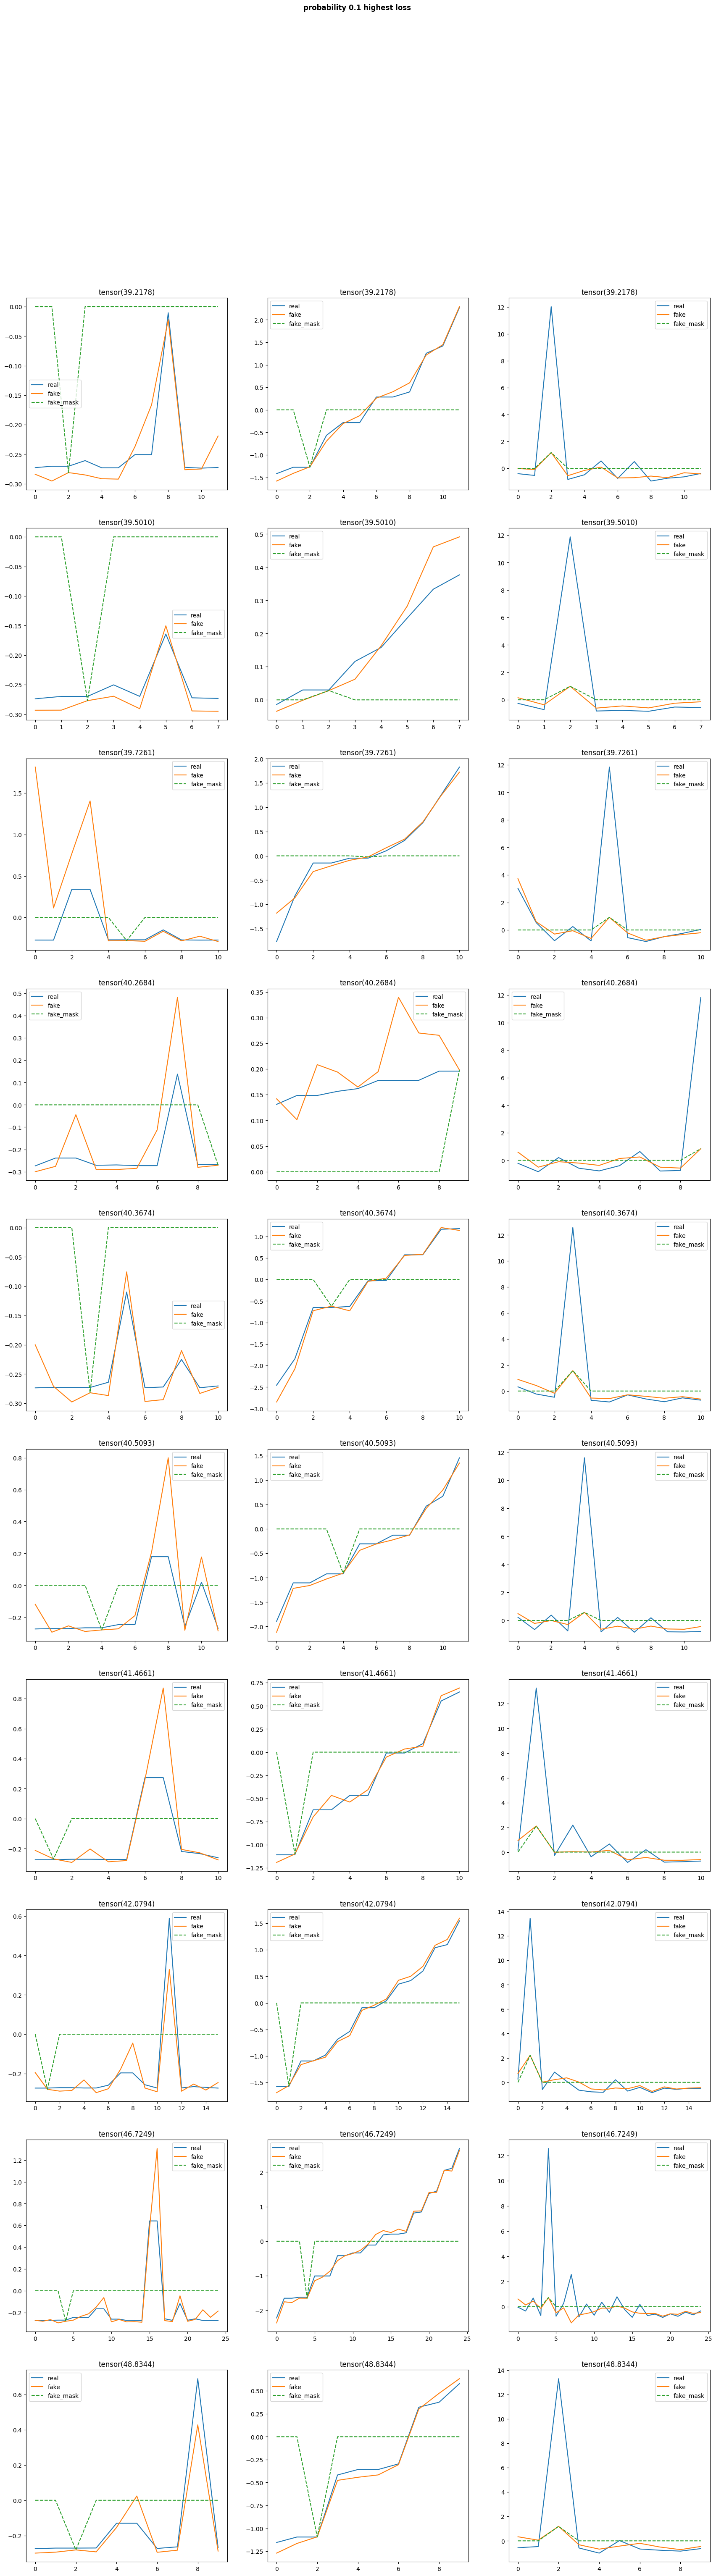

In [44]:
get_most_loss(events_01, 10)

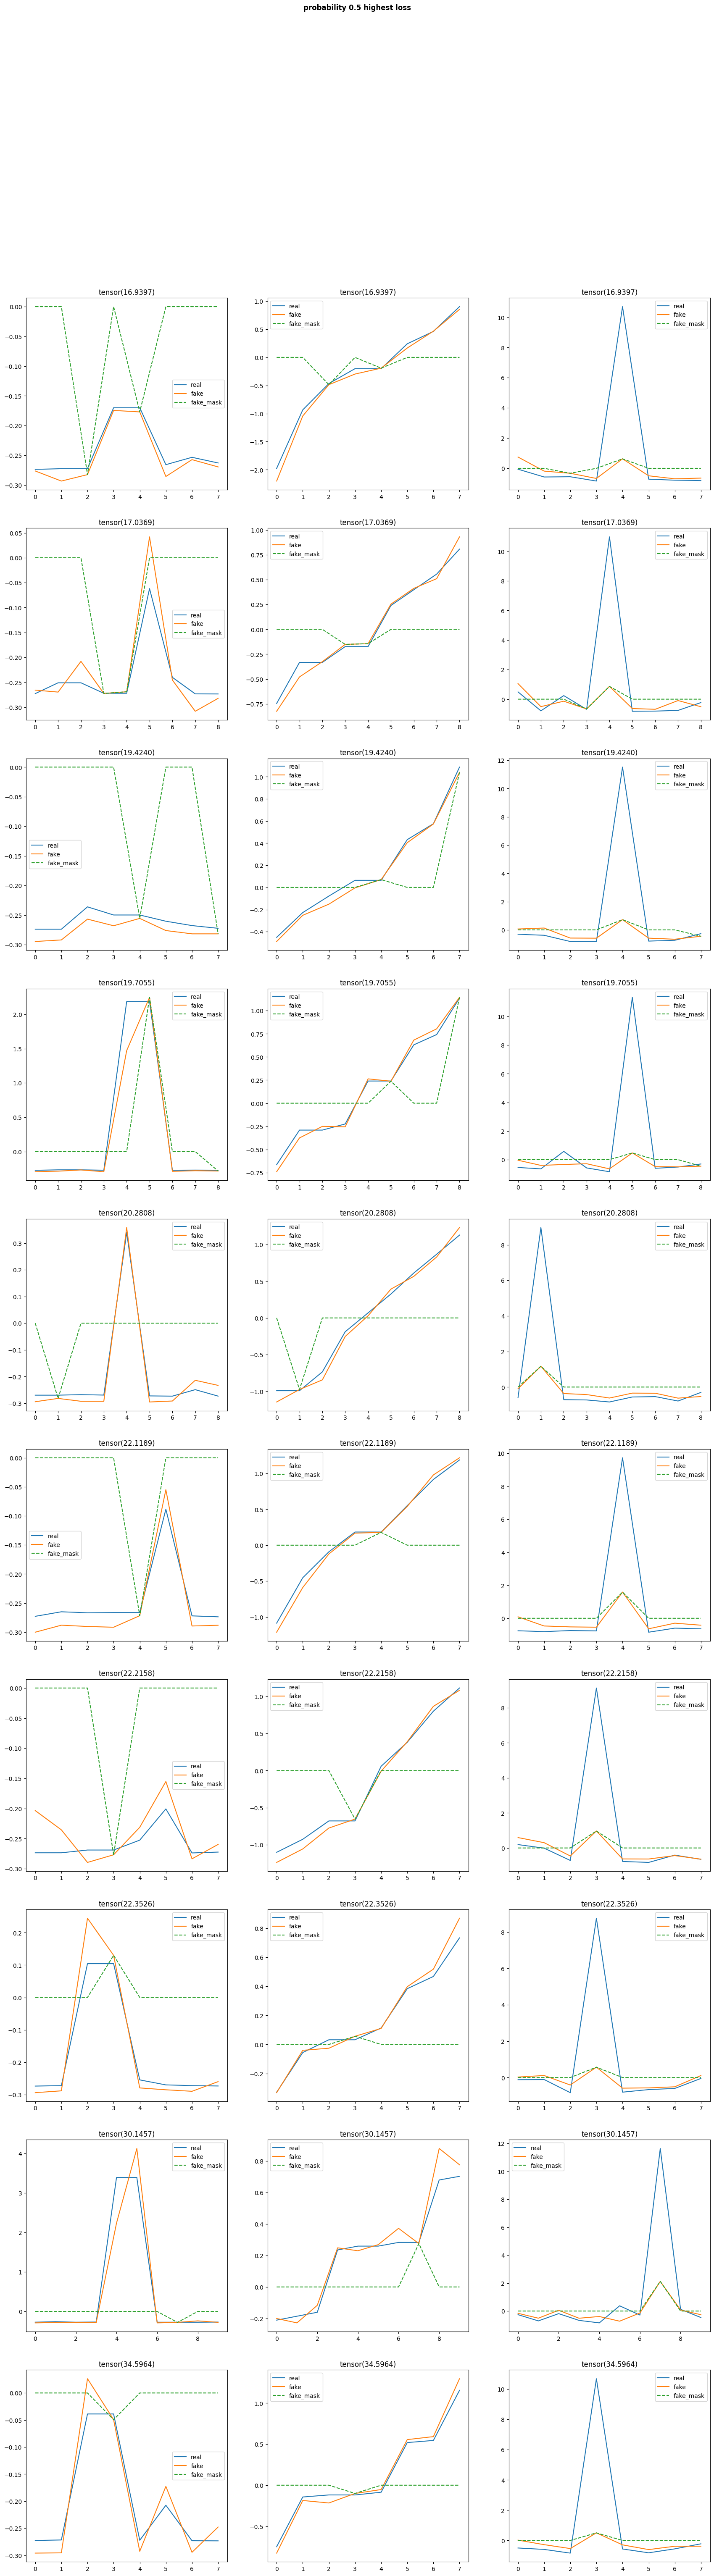

In [47]:
get_most_loss(events_05, 10, '0.5')

In [ ]:
def by_ev_return(recon_x, x, mask_tensor):
    LossMSE= nn.MSELoss(reduction='none') 
    none_loss = LossMSE(recon_x, x)
    print(none_loss.shape, mask_tensor.shape)
    none_loss_mask = none_loss*mask_tensor.to
    print(none_loss_mask)
    none_loss_mask = torch.sum(none_loss_mask, dim = 2)
    none_loss_mask = torch.sum(none_loss_mask, dim = 1)
    print(none_loss_mask)
    mask_tensor = torch.sum(mask_tensor, dim = 2)
    mask_tensor = torch.sum(mask_tensor, dim = 1)
    mean_loss =  none_loss_mask/(mask_tensor+ 1e-6)
    return mean_loss
def by_chanal(recon_x, x, mask_tensor):
    LossMSE= nn.MSELoss(reduction='none') 
    none_loss = LossMSE(recon_x, x)
    none_loss_mask = none_loss*mask_tensor
    # none_loss_mask = torch.sum(none_loss_mask, dim = 2)
    none_loss_mask = torch.sum(none_loss_mask, dim = 1)
    # mask_tensor = torch.sum(mask_tensor, dim = 2)
    mask_tensor = torch.sum(mask_tensor, dim = 1)
    mean_loss =  none_loss_mask/(mask_tensor+ 1e-6) # batch, 6
    mean_loss = mean_loss.mean()
    return mean_loss

In [33]:
#look last
loss_mean, index_all, data_list, recon_list, mask_list = events_01
sorted_x, indices = torch.sort(loss_mean)
ind = indices[-1]
print('loss', loss_mean[ind])
x=data_list[ind]
mask = mask_list[ind]
recon = recon_list[ind]
print(mask[:,4])
print([i.shape for i in (recon.unsqueeze(0), x.unsqueeze(0), mask.unsqueeze(0))])
l = by_ev_return(recon.unsqueeze(0), x.unsqueeze(0), mask.unsqueeze(0))
print('loss', l)


loss tensor(48.8344)
tensor([False, False, False,  True, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False])
[torch.Size([1, 48, 6]), torch.Size([1, 48, 6]), torch.Size([1, 48, 6])]
torch.Size([1, 48, 6]) torch.Size([1, 48, 6])
tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0775e-04, 3.3908e-06,
          1.4650e+02],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
          0.0000e+00],
         [0.0000e+

In [ ]:
def by_chanal(recon_x, x, mask_tensor):
    LossMSE= nn.MSELoss(reduction='none') 
    none_loss = LossMSE(recon_x, x)
    print(none_loss.shape, mask_tensor.shape)
    none_loss_mask = none_loss*mask_tensor.to
    print(none_loss_mask)
    none_loss_mask = torch.sum(none_loss_mask, dim = 2)
    none_loss_mask = torch.sum(none_loss_mask, dim = 1)
    print(none_loss_mask)
    mask_tensor = torch.sum(mask_tensor, dim = 2)
    mask_tensor = torch.sum(mask_tensor, dim = 1)
    mean_loss =  none_loss_mask/(mask_tensor+ 1e-6)
    return mean_loss

In [105]:
loss_mean, index_all = validation_step(-1, pipline.val_loaders[0], 'pr', probability=0.7)
loss_mean_ph, index_all_ph = validation_step(-1, pipline.val_loaders[1], '_ph', probability=0.7)

/tmp/ipykernel_39820/951860104.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

In [21]:
loss_mean_ph, index_all_ph = validation_step(-1, pipline.val_loaders[1], '_ph', probability=0.05)

/tmp/ipykernel_48183/3463236894.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

In [48]:
events_01_pr = validation_step_event_return(-1, pipline.val_loaders[0], 'pr', probability=0.1)
events_05_pr = validation_step_event_return(-1, pipline.val_loaders[0], 'pr', probability=0.5)

/tmp/ipykernel_39820/1738989306.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)


VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

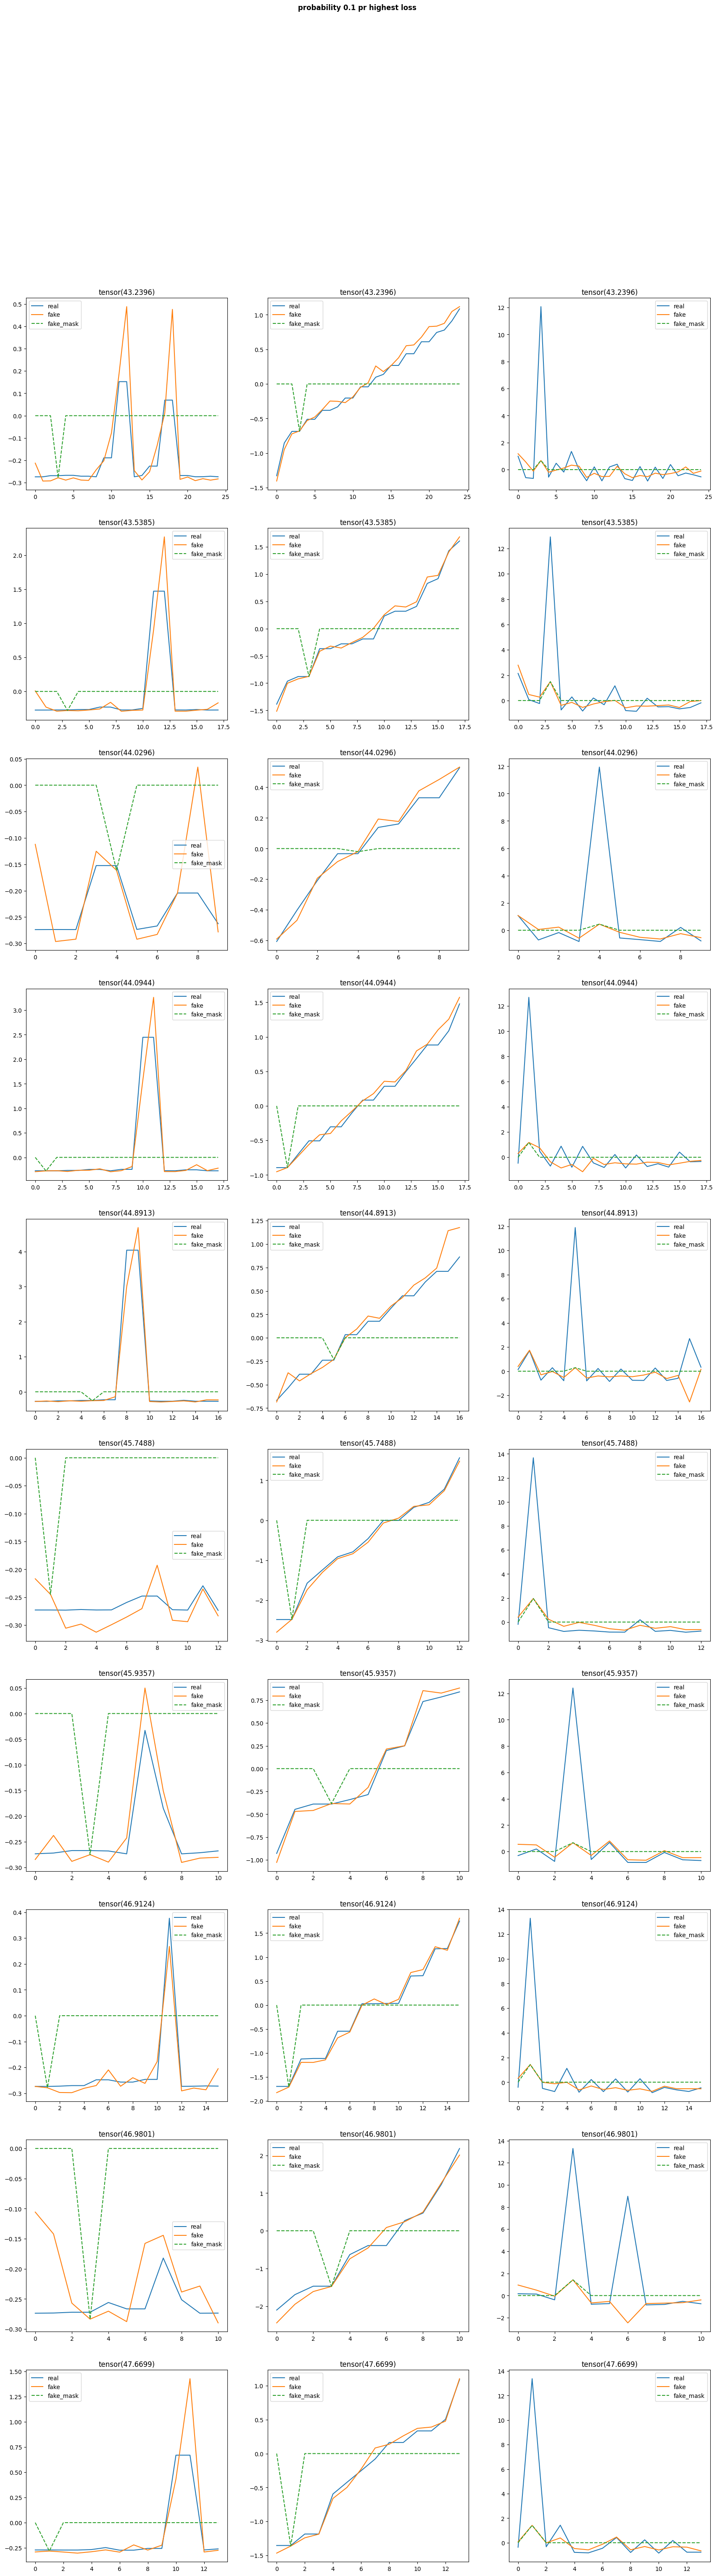

In [49]:
get_most_loss(events_01_pr, 10, '0.1 pr')

/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


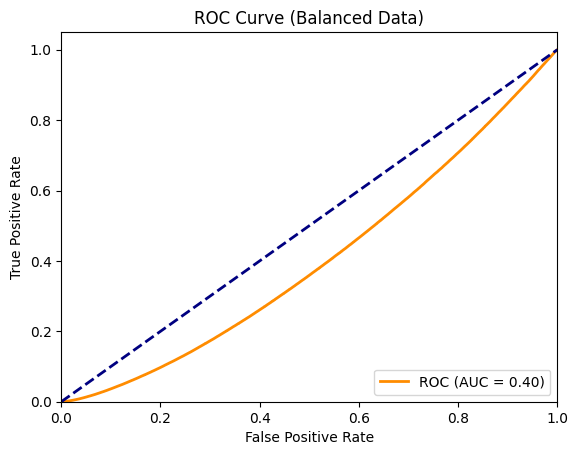

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import make_pipeline

# Предположим, что:
# loss_mean - массив оценок для класса 0 (размер N0)
# loss_mean_ph - массив оценок для класса 1 (размер N1, где N1 < N0)

# Создаем объединенный датасет
y_scores = np.concatenate([loss_mean, loss_mean_ph])  # Объединенные оценки
y_true = np.concatenate([np.ones_like(loss_mean), np.zeros_like(loss_mean_ph)])  # Метки [0, 1]

# Разделение на признаки и метки (X должен быть 2D-массивом)
X = y_scores.reshape(-1, 1)  # Используем оценки как единственный признак
y = y_true

# Балансировка и построение ROC
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42
)

# Обучаем модель на сбалансированных данных
model = LogisticRegression()
model.fit(X_train, y_train)

# Предсказание вероятностей для теста
y_proba = model.predict_proba(X_test)[:, 1]

# Построение ROC-кривой
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Balanced Data)')
plt.legend(loc="lower right")
plt.show()

tensor(0.0091) tensor(0.0289)


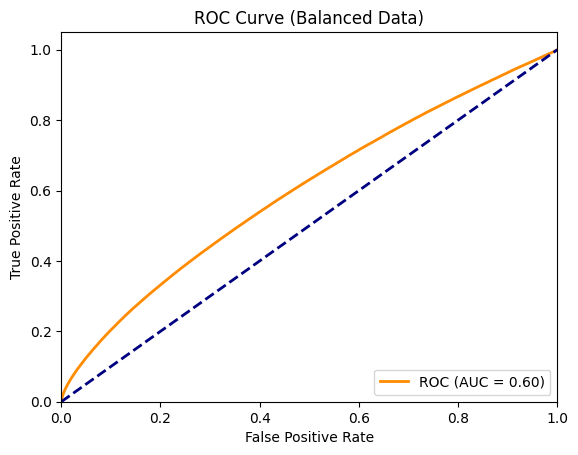

In [107]:
print(loss_mean.mean(), loss_mean_ph.mean())
y_scores = np.concatenate([loss_mean, loss_mean_ph])  # Объединенные оценки
y_true = np.concatenate([np.zeros_like(loss_mean), np.ones_like(loss_mean_ph)])  # Метки [0, 1]
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Balanced Data)')
plt.legend(loc="lower right")
plt.show()

In [25]:
loss_mean, index_all, signal_mean = validation_step_by_signal(-1, pipline.val_loaders[0], 'pr', probability=0.05)
loss_mean_ph, index_all_ph, signal_mean_ph = validation_step_by_signal(-1, pipline.val_loaders[1], '_ph', probability=0.05)

/tmp/ipykernel_33485/2079687844.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.data[st:fn]), torch.tensor(mc_params[1]), torch.tensor(params_CR)


TypeError: cannot unpack non-iterable NoneType object

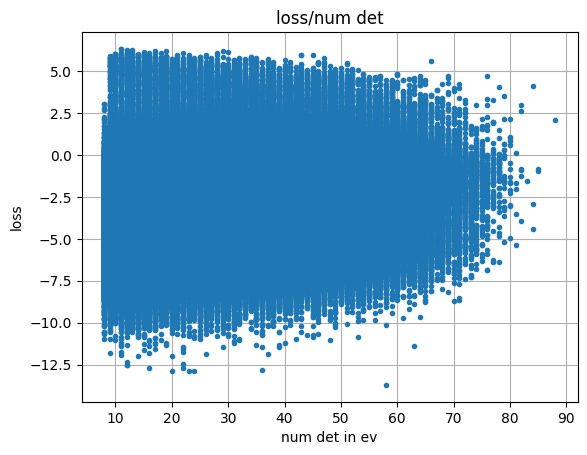

In [19]:
plt.plot(index_all, torch.log(loss_mean), '.')
plt.title('loss/num det')
plt.xlabel('num det in ev')
plt.ylabel('loss')
plt.grid()

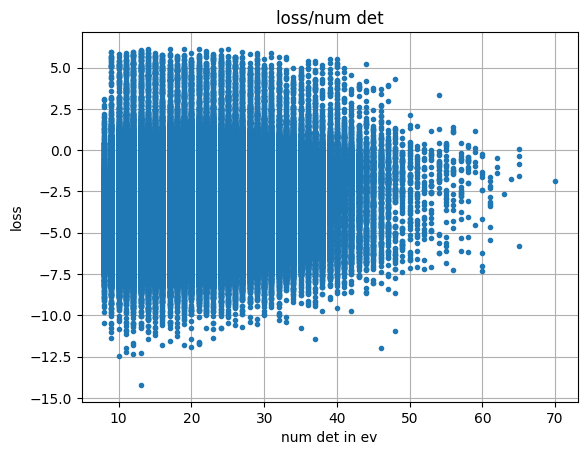

In [20]:
plt.plot(index_all_ph, torch.log(loss_mean_ph), '.')
plt.title('loss/num det')
plt.xlabel('num det in ev')
plt.ylabel('loss')
plt.grid()

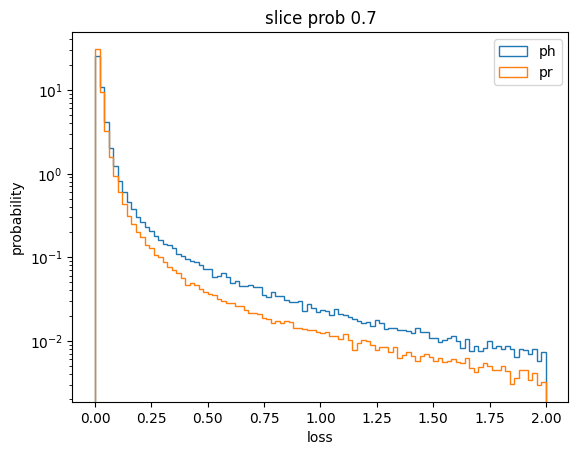

In [38]:
range_hist = (-0,2)
plt.hist(loss_mean_ph/index_all_ph, label='ph', density=True, histtype = 'step',  log=True, bins=100,range=range_hist)
plt.hist(loss_mean/index_all, label='pr', density=True, histtype = 'step', log=True, bins=100,range=range_hist)
plt.xlabel('loss')
plt.ylabel('probability')
plt.title('slice prob 0.7')
plt.legend()

In [39]:
loss_mean.mean(), loss_mean_ph.mean()

(tensor(-0.0054), tensor(-0.2870))

In [38]:
# np.array(loss_mean).quantile(0.8)
np.quantile(np.array(loss_mean_ph), 0.8)

-0.01941655389964581

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm  # Для логарифмической шкалы цветов
# counts = 
def hist2D(x_data, y_data):
    part = 'pr'

    fig = plt.figure(figsize=(12, 12), facecolor='white')
    gs = fig.add_gridspec(2, 2, 
                        width_ratios=(4, 1),
                        height_ratios=(1, 4),
                        left=0.1, right=0.85,
                        bottom=0.1, top=0.9,
                        wspace=0.05, hspace=0.05)

    # Основная 2D гистограмма
    ax_main = fig.add_subplot(gs[1, 0])
    x = x_data.numpy()
    y = y_data.numpy()

    bins = 100  # Увеличим количество бинов для детализации
    # range = [[0, 10], [0, 5]]

    # Используем логическую нормализацию и минимальный порог
    counts, xedges, yedges, im = ax_main.hist2d(
        x, y,
        bins=bins,
        range=None,
        density=True,
        cmap='viridis',
        # norm=LogNorm(vmin=1e-3, vmax=counts.max()),  # Логарифмическая шкала цветов
        alpha=0.9
    )

    # Добавляем контуры для лучшей читаемости
    ax_main.contour(
        counts.T, 
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        levels=5,
        colors='black',
        linewidths=0.5,
        alpha=0.7
    )

    # Цветовая шкала
    ax_cbar = fig.add_axes([0.87, 0.1, 0.03, 0.8])
    cbar = fig.colorbar(im, cax=ax_cbar, label='Density (log scale)')
    cbar.outline.set_visible(False)

    # Маргинальные распределения
    ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
    ax_top.hist(x, bins=xedges, density=True, color='#2ca02c', alpha=0.8)
    ax_top.set(ylabel='Density', facecolor='white')
    ax_top.grid(True, linestyle='--', alpha=0.5)
    ax_top.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)
    ax_right.hist(y, bins=yedges, density=True, 
                orientation='horizontal', color='#d62728', alpha=0.8)
    ax_right.set(xlabel='Density', facecolor='white')
    ax_right.grid(True, linestyle='--', alpha=0.5)
    ax_right.tick_params(axis='y', which='both', left=False, labelleft=False)

    # Настройка осей
    ax_main.set(
        xlabel='x', 
        ylabel='y',
        # xlim=(0, 5),
        # ylim=(0, 5),
        facecolor='white'
    )

    # Убираем рамки
    for ax in [ax_main, ax_top, ax_right]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_color('#444444')
        ax.spines['left'].set_color('#444444')

    ax_top.set_title('Joint Distribution Analysis (0-5 range)', pad=20, fontsize=14)

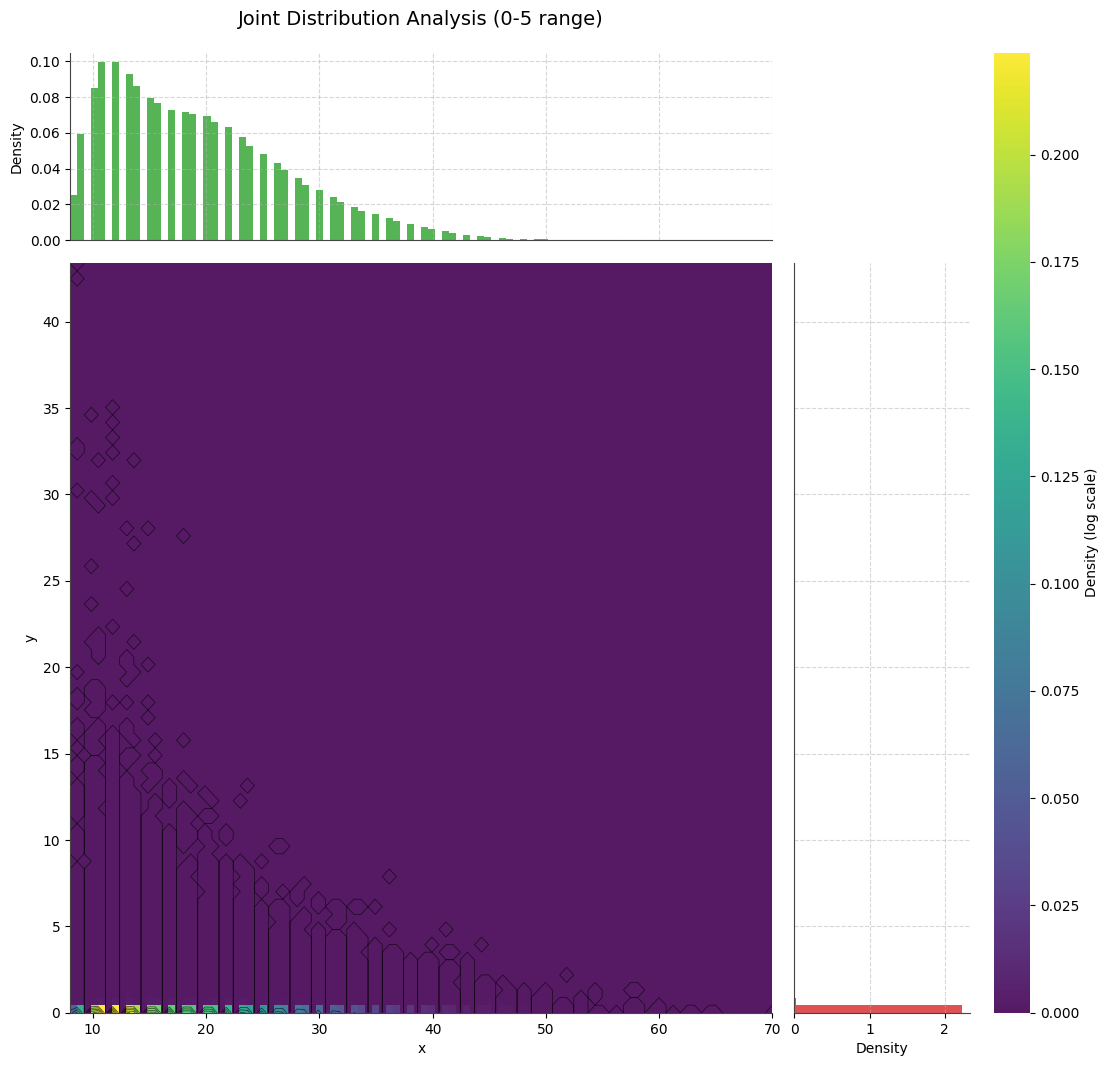

In [85]:
hist2D(index_all_ph, loss_mean_ph)

In [18]:
loss_by_prob = []
index_by_prob = []
loss_by_prob_std = []
for prob in tqdm(np.arange(0.05, 1.0, 0.05)):
    loss_mean, index_all = validation_step(-1, pipline.val_loaders[0], 'pr', prob)
    loss_by_prob.append(loss_mean.mean())
    index_by_prob.append(index_all.mean())
    loss_by_prob_std.append(loss_mean.std())

/tmp/ipykernel_52281/3230061032.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for prob in tqdm(np.arange(0.05, 1.0, 0.05)):


  0%|          | 0/19 [00:00<?, ?it/s]

/tmp/ipykernel_52281/2409375520.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.data[st:fn]), torch.tensor(mc_params[1]), torch.tensor(params_CR)


...

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

In [17]:
loss_by_prob_ph = []
index_by_prob_ph = []
loss_by_prob_ph_std = []
for prob in tqdm(np.arange(0.05,1.0, 0.05)):
    loss_mean_ph, index_all_ph = validation_step(-1, pipline.val_loaders[1], '_ph', prob)
    loss_by_prob_ph.append(loss_mean_ph.mean())
    loss_by_prob_ph_std.append(loss_mean_ph.std())
    index_by_prob_ph.append(index_all_ph.mean())

/tmp/ipykernel_29902/2505103845.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for prob in tqdm(np.arange(0.05,1.0, 0.05)):


  0%|          | 0/19 [00:00<?, ?it/s]

/tmp/ipykernel_29902/2444825875.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.data[st:fn]), torch.tensor(mc_params[1]), torch.tensor(params_CR)


...

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

In [9]:
prob = 0.6
loss_mean, index_all = validation_step(-1, pipline.val_loaders[0], 'pr', prob)
loss_mean_ph, index_all_ph = validation_step(-1, pipline.val_loaders[1], '_ph', prob)

/tmp/ipykernel_29902/2444825875.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.data[st:fn]), torch.tensor(mc_params[1]), torch.tensor(params_CR)


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

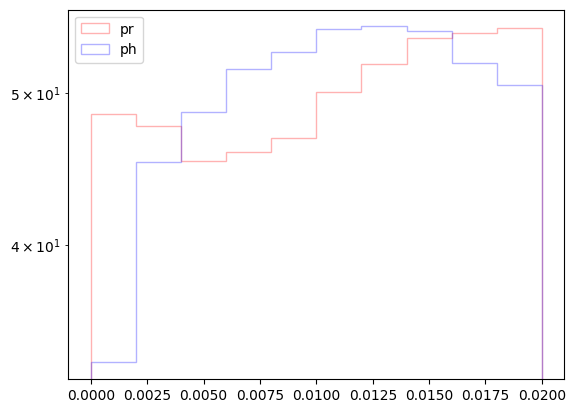

In [14]:
plt.hist(loss_mean, color='#FF0000', alpha = 0.3, label='pr', range=(0, 0.02), density=True, log=True, histtype='step')
plt.hist(loss_mean_ph, color='#0000FF', alpha = 0.3, label='ph', range=(0, 0.02), density=True, log=True, histtype='step')
plt.legend()

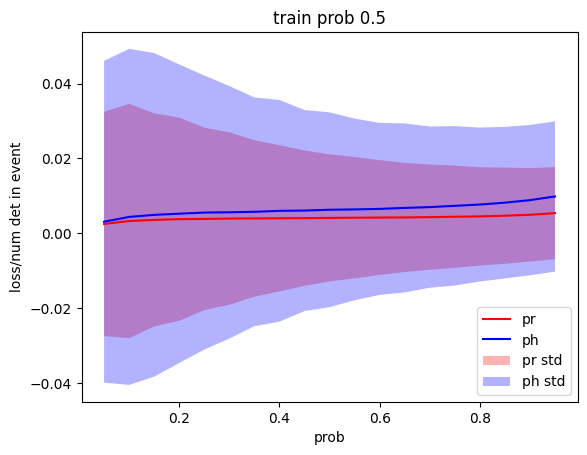

In [32]:
plt.plot(np.arange(0.05,1.0, 0.05), np.array(loss_by_prob)/np.array(index_by_prob), 'r', label = 'pr')
plt.plot(np.arange(0.05,1.0, 0.05), np.array(loss_by_prob_ph)/np.array(index_by_prob_ph), 'b', label = 'ph')
#.fill_between(x, y-error, y+error)
plt.fill_between(np.arange(0.05,1.0, 0.05), (np.array(loss_by_prob)-np.array(loss_by_prob_std))/np.array(index_by_prob), 
                 (np.array(loss_by_prob)+np.array(loss_by_prob_std))/np.array(index_by_prob), 
                 alpha=0.3, facecolor='#FF0000', label = 'pr std')
plt.fill_between(np.arange(0.05,1.0, 0.05), (np.array(loss_by_prob_ph)-np.array(loss_by_prob_ph_std))/np.array(index_by_prob_ph), 
                 (np.array(loss_by_prob_ph)+np.array(loss_by_prob_ph_std))/np.array(index_by_prob_ph)
                 , alpha=0.3, facecolor='#0000FF', label = 'ph std')
plt.ylabel('loss/num det in event')
plt.xlabel('prob')
plt.title('train prob 0.5')
plt.legend()

In [42]:
loss_mean, index_all = validation_step(-1, pipline.val_loaders[0], 'pr', 0.5)

/tmp/ipykernel_69010/2444825875.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.data[st:fn]), torch.tensor(mc_params[1]), torch.tensor(params_CR)


In [72]:
loss_mean_ph, index_all_ph = validation_step(-1, pipline.val_loaders[1], 'ph', 0.5)

/tmp/ipykernel_69010/2444825875.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:111: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(self.data[st:fn]), torch.tensor(mc_params[1]), torch.tensor(params_CR)


In [64]:
def by_num(index_all, loss_mean):
    loss_by_num = {}
    for i in tqdm(range(index_all.size(0))):
        num = index_all[i]
        l = loss_mean[i]
        k= str(int(num.item()))
        if k in loss_by_num.keys():
            loss_by_num[k] = torch.concat((loss_by_num[k], l.unsqueeze(-1)))
        else:
            loss_by_num[k] = l.unsqueeze(-1)
    res = {}
    for k,v in loss_by_num.items():
        res[k] = {}
        res[k]['mean'] = v.mean()
        res[k]['std'] = v.std()
    return res

In [65]:
res_pr = by_num(index_all, loss_mean)

/tmp/ipykernel_69010/2822637928.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm(range(index_all.size(0))):


  0%|          | 0/779074 [00:00<?, ?it/s]

In [66]:
res_pr

{'10': {'mean': tensor(0.1260), 'std': tensor(0.7414)},
 '18': {'mean': tensor(0.1143), 'std': tensor(0.4574)},
 '23': {'mean': tensor(0.1133), 'std': tensor(0.3897)},
 '11': {'mean': tensor(0.1364), 'std': tensor(0.7273)},
 '31': {'mean': tensor(0.1009), 'std': tensor(0.2741)},
 '29': {'mean': tensor(0.0983), 'std': tensor(0.2803)},
 '16': {'mean': tensor(0.1250), 'std': tensor(0.5242)},
 '32': {'mean': tensor(0.0993), 'std': tensor(0.2639)},
 '57': {'mean': tensor(0.0929), 'std': tensor(0.1630)},
 '8': {'mean': tensor(0.0135), 'std': tensor(0.0551)},
 '20': {'mean': tensor(0.1125), 'std': tensor(0.4203)},
 '40': {'mean': tensor(0.0962), 'std': tensor(0.2111)},
 '19': {'mean': tensor(0.1112), 'std': tensor(0.4368)},
 '27': {'mean': tensor(0.1034), 'std': tensor(0.3116)},
 '9': {'mean': tensor(0.0948), 'std': tensor(0.6993)},
 '22': {'mean': tensor(0.1079), 'std': tensor(0.3819)},
 '35': {'mean': tensor(0.0986), 'std': tensor(0.2398)},
 '44': {'mean': tensor(0.0943), 'std': tensor(0.19

In [73]:
res_ph = by_num(index_all_ph, loss_mean_ph)

/tmp/ipykernel_69010/2822637928.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i in tqdm(range(index_all.size(0))):


  0%|          | 0/364387 [00:00<?, ?it/s]

In [74]:
mean = [i['mean'] for i in res_pr.values()]
std = [i['std'] for i in res_pr.values()]
num = [int(i) for i in res_pr.keys()]

mean_ph = [i['mean'] for i in res_ph.values()]
std_ph = [i['std'] for i in res_ph.values()]
num_ph = [int(i) for i in res_ph.keys()]

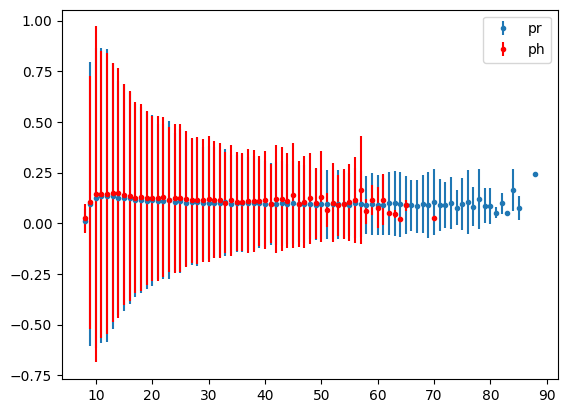

In [75]:
plt.errorbar(num, mean, std, None, '.', label = 'pr')
plt.errorbar(num_ph, mean_ph, std_ph, None, '.r', label = 'ph')
plt.legend()

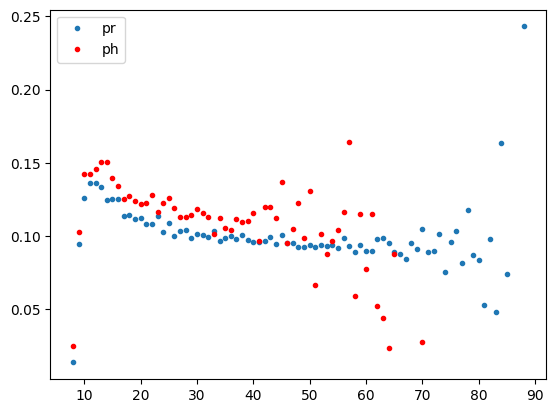

In [76]:
plt.errorbar(num, mean, None, None, '.', label = 'pr')
plt.errorbar(num_ph, mean_ph, None, None, '.r', label = 'ph')
plt.legend()

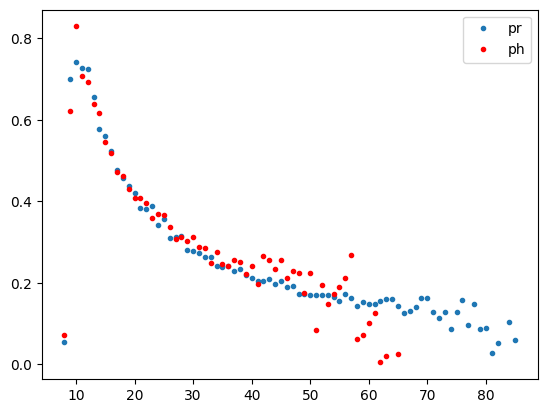

In [77]:
plt.errorbar(num, std, None, None, '.', label = 'pr')
plt.errorbar(num_ph, std_ph, None, None, '.r', label = 'ph')
plt.legend()

In [8]:
def many_player(x, prob: float, num: int):
    loss_many = []
    for i in range(num):
        x_mask, index = random_mask_index(x, probability=prob, mask_v = pipline.config['padding_value'])
        x_mask = x_mask.to(device)
        # index_all = torch.concat((index_all, index))
        x = x.to(device)
        # part = torch.where(part == 1, 0, 1).to(device) # 0- photon, 1- proton
        # params_CR = params_CR.to(device)
        recon_x = pipline.model(x, x_mask)
        loss = Loss(recon_x, x, x_mask).to('cpu')
        loss_many.append(loss)
    return loss_many


In [4]:
from pipline import PiplineMask
config = 'config.yaml'
pipline = PiplineMask(config, need_train_DS=False)
pipline.model.load('/home/rfit/Telescope_Array/phd_work/Models/BERT/BERT_coordinat_change_sort/last')

Using device: cuda


2025-07-13 15:40:21.891247: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752410421.908033   14271 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752410421.913057   14271 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752410421.925689   14271 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752410421.925713   14271 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752410421.925716   14271 computation_placer.cc:177] computation placer alr

['pipline.py', '__pycache__', 'check.py', 'model.py', 'loss.py', 'config.yaml']
Saving Path: /home/rfit/Telescope_Array/phd_work/Models/BERT/BERT_test
6 64 16 6


In [10]:
loss_by_prob = []
index_by_prob = []
loss_by_prob_std = []
for prob in tqdm(np.arange(0.05, 1.0, 0.05)):
    loss_mean, index_all = validation_step(-1, pipline.val_loaders[0], 'pr', prob)
    loss_by_prob.append(loss_mean.mean())
    index_by_prob.append(index_all.mean())
    loss_by_prob_std.append(loss_mean.std())

/tmp/ipykernel_14271/3230061032.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for prob in tqdm(np.arange(0.05, 1.0, 0.05)):


  0%|          | 0/19 [00:00<?, ?it/s]

/tmp/ipykernel_14271/951860104.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

...

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

In [11]:
loss_by_prob_ph = []
index_by_prob_ph = []
loss_by_prob_ph_std = []
for prob in tqdm(np.arange(0.05,1.0, 0.05)):
    loss_mean_ph, index_all_ph = validation_step(-1, pipline.val_loaders[1], '_ph', prob)
    loss_by_prob_ph.append(loss_mean_ph.mean())
    loss_by_prob_ph_std.append(loss_mean_ph.std())
    index_by_prob_ph.append(index_all_ph.mean())

/tmp/ipykernel_14271/2505103845.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for prob in tqdm(np.arange(0.05,1.0, 0.05)):


  0%|          | 0/19 [00:00<?, ?it/s]

/tmp/ipykernel_14271/951860104.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)


...

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

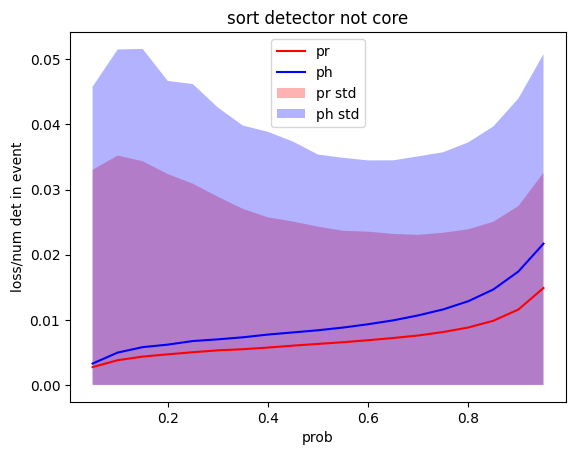

In [13]:
plt.plot(np.arange(0.05,1.0, 0.05), np.array(loss_by_prob)/np.array(index_by_prob), 'r', label = 'pr')
plt.plot(np.arange(0.05,1.0, 0.05), np.array(loss_by_prob_ph)/np.array(index_by_prob_ph), 'b', label = 'ph')
#.fill_between(x, y-error, y+error)
plt.fill_between(np.arange(0.05,1.0, 0.05), np.zeros_like(np.array(loss_by_prob)), 
                 (np.array(loss_by_prob)+np.array(loss_by_prob_std))/np.array(index_by_prob), 
                 alpha=0.3, facecolor='#FF0000', label = 'pr std')
plt.fill_between(np.arange(0.05,1.0, 0.05), np.zeros_like(np.array(loss_by_prob)), 
                 (np.array(loss_by_prob_ph)+np.array(loss_by_prob_ph_std))/np.array(index_by_prob_ph)
                 , alpha=0.3, facecolor='#0000FF', label = 'ph std')
plt.ylabel('loss/num det in event')
plt.xlabel('prob')
plt.title('sort detector not core')
plt.legend()

In [14]:
loss_mean_ph, index_all_ph = validation_step(-1, pipline.val_loaders[1], 'ph', 0.65)
loss_mean, index_all = validation_step(-1, pipline.val_loaders[0], 'pr', 0.65)

/tmp/ipykernel_14271/951860104.py:6: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")


VAL Epoch 0 in ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

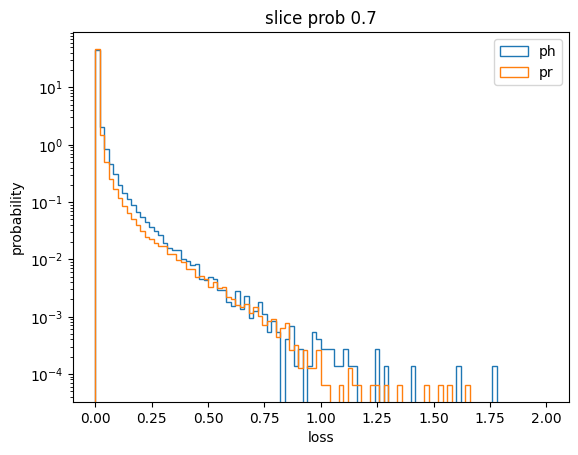

In [22]:
range_hist = (-0,2)
plt.hist(loss_mean_ph/index_all_ph, label='ph', density=True, histtype = 'step',  log=True, bins=100,range=range_hist)
plt.hist(loss_mean/index_all, label='pr', density=True, histtype = 'step', log=True, bins=100,range=range_hist)
plt.xlabel('loss')
plt.ylabel('probability')
plt.title('slice prob 0.7')
plt.legend()

tensor(0.1866) tensor(0.1914)


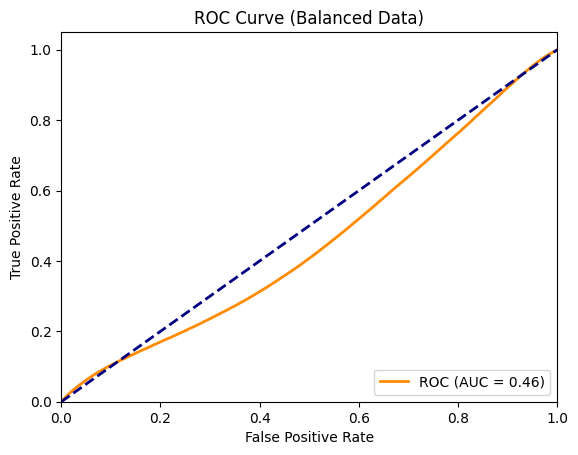

In [19]:
print(loss_mean.mean(), loss_mean_ph.mean())
y_scores = np.concatenate([loss_mean, loss_mean_ph])  # Объединенные оценки
y_true = np.concatenate([np.zeros_like(loss_mean), np.ones_like(loss_mean_ph)])  # Метки [0, 1]
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Balanced Data)')
plt.legend(loc="lower right")
plt.show()

In [38]:
print('pr', ((loss_mean/index_all)<0.005).sum()/len(loss_mean))
print('ph', ((loss_mean_ph/index_all_ph)<0.005).sum()/len(loss_mean_ph))

pr tensor(0.6800)
ph tensor(0.6468)


CHECK ONE WORK DETECTOR

best_chpt = '/home/rfit/Telescope_Array/phd_work/Models/BERT/BERT_one_work/best'

In [60]:
best_chpt = '/home/rfit/Telescope_Array/phd_work/Models/BERT/BERT_one_work/best'

In [61]:
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import os
from torch import nn
from copy import copy
os.environ['CUDA_VISIBLE_DEVICES'] = '3'

In [62]:
cd ../src/BERT/

[Errno 2] No such file or directory: '../src/BERT/'
/home/rfit/Telescope_Array/phd_work/src/BERT


In [63]:
from pipline import PiplineMask
config = 'config.yaml'
pipline = PiplineMask(config, need_train_DS=False)
pipline.model.load(best_chpt)

['pipline.py', '__pycache__', 'check.py', 'model.py', 'loss.py', 'config.yaml']
Saving Path: /home/rfit/Telescope_Array/phd_work/Models/BERT/BERT_one_work
6 64 16 6


In [64]:
def random_mask_index(x: torch.Tensor, probability: float, mask_v: float = -10) -> torch.Tensor:
    # рызыгрывать вероятности а не индексы. 
    device = x.device

    token_mask = (x[:,:,0:1] != mask_v).to(device)  # [batch, maxlen]
    token_mask[:, 0] = False  # исключаем первый токен

    index = torch.sum(token_mask, dim=1)[:,0] # one dim -> batch
    token_mask[torch.arange(index.size(0)), index] = False
    
    probability_tensor = torch.rand_like(x[:,:,0:1]) # batch, len, 1
    probability_tensor = probability_tensor*token_mask # zero in supportive tokens
    token_mask = torch.where(probability_tensor>(1-probability), 1, 0).to(device)
    # to shape -> batch, len, 6
    token_mask = torch.repeat_interleave(token_mask, 6, dim=2).to(device).to(torch.bool)
    return token_mask, index
class MaskLoss():
    def __init__(self, reduction = 'mean', min_sig=0):
        # super().__init__()
        self.LossMSE = nn.MSELoss(reduction='none') 
        self.min_sig = min_sig

    def __call__(self, recon_x, x, mask_tensor):
        none_loss = self.LossMSE(recon_x, x)
        none_loss_mask = none_loss*mask_tensor
        mean_loss =  torch.sum(none_loss_mask)/(torch.sum(mask_tensor) + 1e-6)
        return mean_loss
    def by_ev_return(self, recon_x, x, mask_tensor):
        weight = torch.tensor([0,0,0,1,1,0]).unsqueeze(0).unsqueeze(0).to(recon_x.device)
        none_loss = self.LossMSE(recon_x, x)
        none_loss_mask = none_loss*mask_tensor*weight
        none_loss_mask = torch.sum(none_loss_mask, dim = 2)
        none_loss_mask = torch.sum(none_loss_mask, dim = 1)
        mask_tensor = torch.sum(mask_tensor, dim = 2)
        mask_tensor = torch.sum(mask_tensor, dim = 1)
        mean_loss =  none_loss_mask/(mask_tensor+ 1e-6)
        return mean_loss
    def by_chanal(self, recon_x, x, mask_tensor):
        none_loss = self.LossMSE(recon_x, x)
        none_loss_mask = none_loss*mask_tensor
        # none_loss_mask = torch.sum(none_loss_mask, dim = 2)
        none_loss_mask = torch.sum(none_loss_mask, dim = 1)
        # mask_tensor = torch.sum(mask_tensor, dim = 2)
        mask_tensor = torch.sum(mask_tensor, dim = 1)
        mean_loss =  none_loss_mask/(mask_tensor+ 1e-6) # batch, 6
        # mean_loss = mean_loss.mean()
        return mean_loss
    def div_signal(self, recon_x, x, mask_tensor):
        none_loss = self.LossMSE(recon_x, x)
        none_loss_mask = none_loss*mask_tensor*(x[:,:,3:4]-self.min_sig)
        none_loss_mask = torch.sum(none_loss_mask, dim = 2)
        none_loss_mask = torch.sum(none_loss_mask, dim = 1)
        mask_tensor = torch.sum(mask_tensor, dim = 2)
        mask_tensor = torch.sum(mask_tensor, dim = 1)
        mean_loss =  none_loss_mask/(mask_tensor+ 1e-6)
        return mean_loss
    def by_signal(self, recon_x, x, mask_tensor):
        none_loss = self.LossMSE(recon_x, x)
        none_loss_mask = none_loss*mask_tensor*(x[:,:,3:4]-self.min_sig)
        none_loss_mask = torch.sum(none_loss_mask, dim = 2)
        none_loss_mask = torch.sum(none_loss_mask, dim = 1)
        mask_tensor = torch.sum(mask_tensor, dim = 2)
        mask_tensor = torch.sum(mask_tensor, dim = 1)
        mean_loss =  none_loss_mask/(mask_tensor+ 1e-6)
        return mean_loss
    def get_channel3_loss_and_values(self, recon_x, x, mask_tensor):
        # Выделяем 4-й канал (индекс 3)
        x_ch3 = x[..., 3:4]   # [batch, seq_len, 1]
        # recon_x_ch3 = recon_x[..., 3:4]
        
        # Вычисляем MSE только для 4-го канала
        ch3_loss = self.LossMSE(x, recon_x)  # [batch, seq_len, 6]
        ch3_loss = torch.mean(ch3_loss, dim=-1).unsqueeze(-1)
        print(sum(mask_tensor))
        # Создаем маску для 4-го канала (предполагаем, что маска одинакова для всех каналов)
        mask = mask_tensor[..., 0:1].bool()  # [batch, seq_len, 1]
        print(sum(mask))
        # Применяем маску к ошибкам и значениям x
        errors = ch3_loss[mask]      # вектор ошибок в точках маски
        values = x_ch3[mask]         # вектор значений x[...,3] в точках маски
        print(errors.shape, values.shape)
        return torch.flatten(errors), torch.flatten(values)
Loss = MaskLoss(min_sig = 0)

In [65]:
device ='cuda:0'
def validation_step(epoch: int, val_loader, particle=None, probability = float(pipline.config['probability'])):
    particle = '' if particle is None else particle
    loss_mean = torch.zeros(0,)
    index_all = torch.zeros(0,)
    pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")
    num_examples = 0
    for x, part, params_CR in pbar_val:  # x should be a batch of sequences with padding
        num_examples += x.size(0)
        with torch.no_grad():
            x_mask, index = random_mask_index(x, probability=probability, mask_v = pipline.config['padding_value'])
            x_mask = x_mask.to(device)
            index_all = torch.concat((index_all, index))
            x = x.to(device)
            part = torch.where(part == 1, 0, 1).to(device) # 0- photon, 1- proton
            params_CR = params_CR.to(device)
            recon_x = pipline.model(x, x_mask)
            loss = Loss.by_ev_return(recon_x, x, x_mask)
            pbar_val.set_description(f"VAL {particle} Loss:")
            loss_mean = torch.concat((loss_mean, loss.to('cpu')))

            # return signal
            # sigqnal = x[:,:,3*4]*x_mask[:,:,3:4]
            
    return loss_mean, index_all

In [15]:
loss_mean, index_all = validation_step(-1, pipline.val_loaders[0], 'pr', probability=0.7)
loss_mean_ph, index_all_ph = validation_step(-1, pipline.val_loaders[1], '_ph', probability=0.7)

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


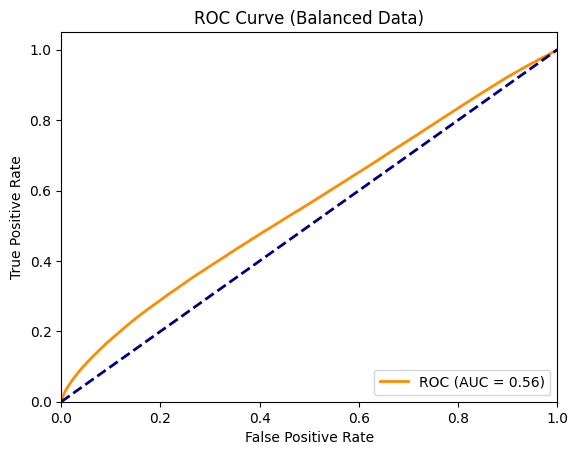

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import make_pipeline

# Предположим, что:
# loss_mean - массив оценок для класса 0 (размер N0)
# loss_mean_ph - массив оценок для класса 1 (размер N1, где N1 < N0)

# Создаем объединенный датасет
y_scores = np.concatenate([loss_mean, loss_mean_ph])  # Объединенные оценки
y_true = np.concatenate([np.zeros_like(loss_mean), np.ones_like(loss_mean_ph)])  # Метки [0, 1]

# Разделение на признаки и метки (X должен быть 2D-массивом)
X = y_scores.reshape(-1, 1)  # Используем оценки как единственный признак
y = y_true

# Балансировка и построение ROC
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42
)

# Обучаем модель на сбалансированных данных
model = LogisticRegression()
model.fit(X_train, y_train)

# Предсказание вероятностей для теста
y_proba = model.predict_proba(X_test)[:, 1]

# Построение ROC-кривой
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Balanced Data)')
plt.legend(loc="lower right")
plt.show()

In [18]:
pipline.model.load('/home/rfit/Telescope_Array/phd_work/Models/BERT/BERT_8l_0.5/last')

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


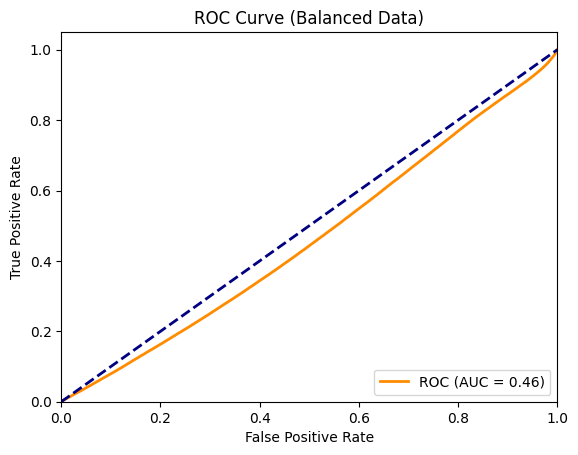

In [20]:
loss_mean, index_all = validation_step(-1, pipline.val_loaders[0], 'pr', probability=0.7)
loss_mean_ph, index_all_ph = validation_step(-1, pipline.val_loaders[1], '_ph', probability=0.7)



y_scores = np.concatenate([loss_mean, loss_mean_ph])  # Объединенные оценки
y_true = np.concatenate([np.zeros_like(loss_mean), np.ones_like(loss_mean_ph)])  # Метки [0, 1]

# Разделение на признаки и метки (X должен быть 2D-массивом)
X = y_scores.reshape(-1, 1)  # Используем оценки как единственный признак
y = y_true

# Балансировка и построение ROC
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42
)

# Обучаем модель на сбалансированных данных
model = LogisticRegression()
model.fit(X_train, y_train)

# Предсказание вероятностей для теста
y_proba = model.predict_proba(X_test)[:, 1]

# Построение ROC-кривой
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Balanced Data)')
plt.legend(loc="lower right")
plt.show()

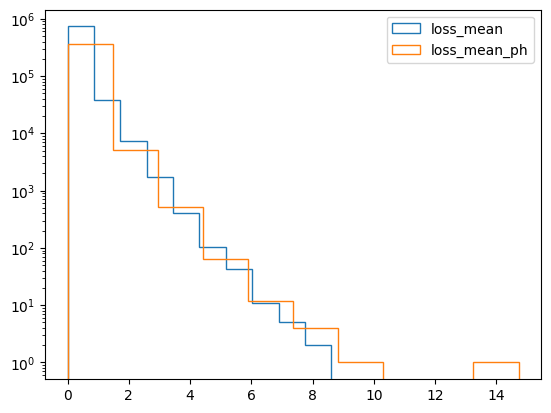

In [23]:
plt.hist(loss_mean, label= 'loss_mean', histtype = 'step',  log=True,)
plt.hist(loss_mean_ph, label = 'loss_mean_ph', histtype = 'step',  log=True,)
plt.legend()

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

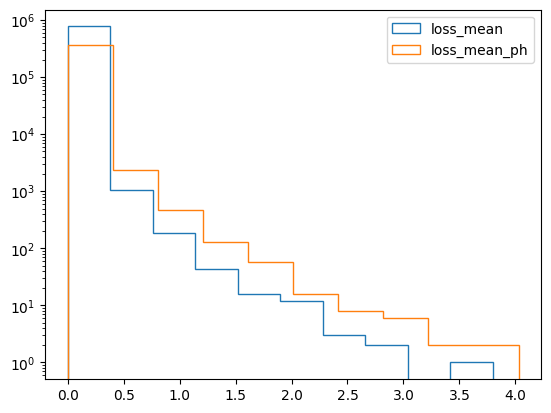

In [24]:
pipline.model.load(best_chpt)
loss_mean_one_work, index_all_one_work = validation_step(-1, pipline.val_loaders[0], 'pr', probability=0.7)
loss_mean_ph_one_work, index_all_ph_one_work = validation_step(-1, pipline.val_loaders[1], '_ph', probability=0.7)
plt.hist(loss_mean_one_work, label= 'loss_mean', histtype = 'step',  log=True,)
plt.hist(loss_mean_ph_one_work, label = 'loss_mean_ph', histtype = 'step',  log=True,)
plt.legend()


0.1


VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

0.30000000000000004


VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

...

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

0.7000000000000001


VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

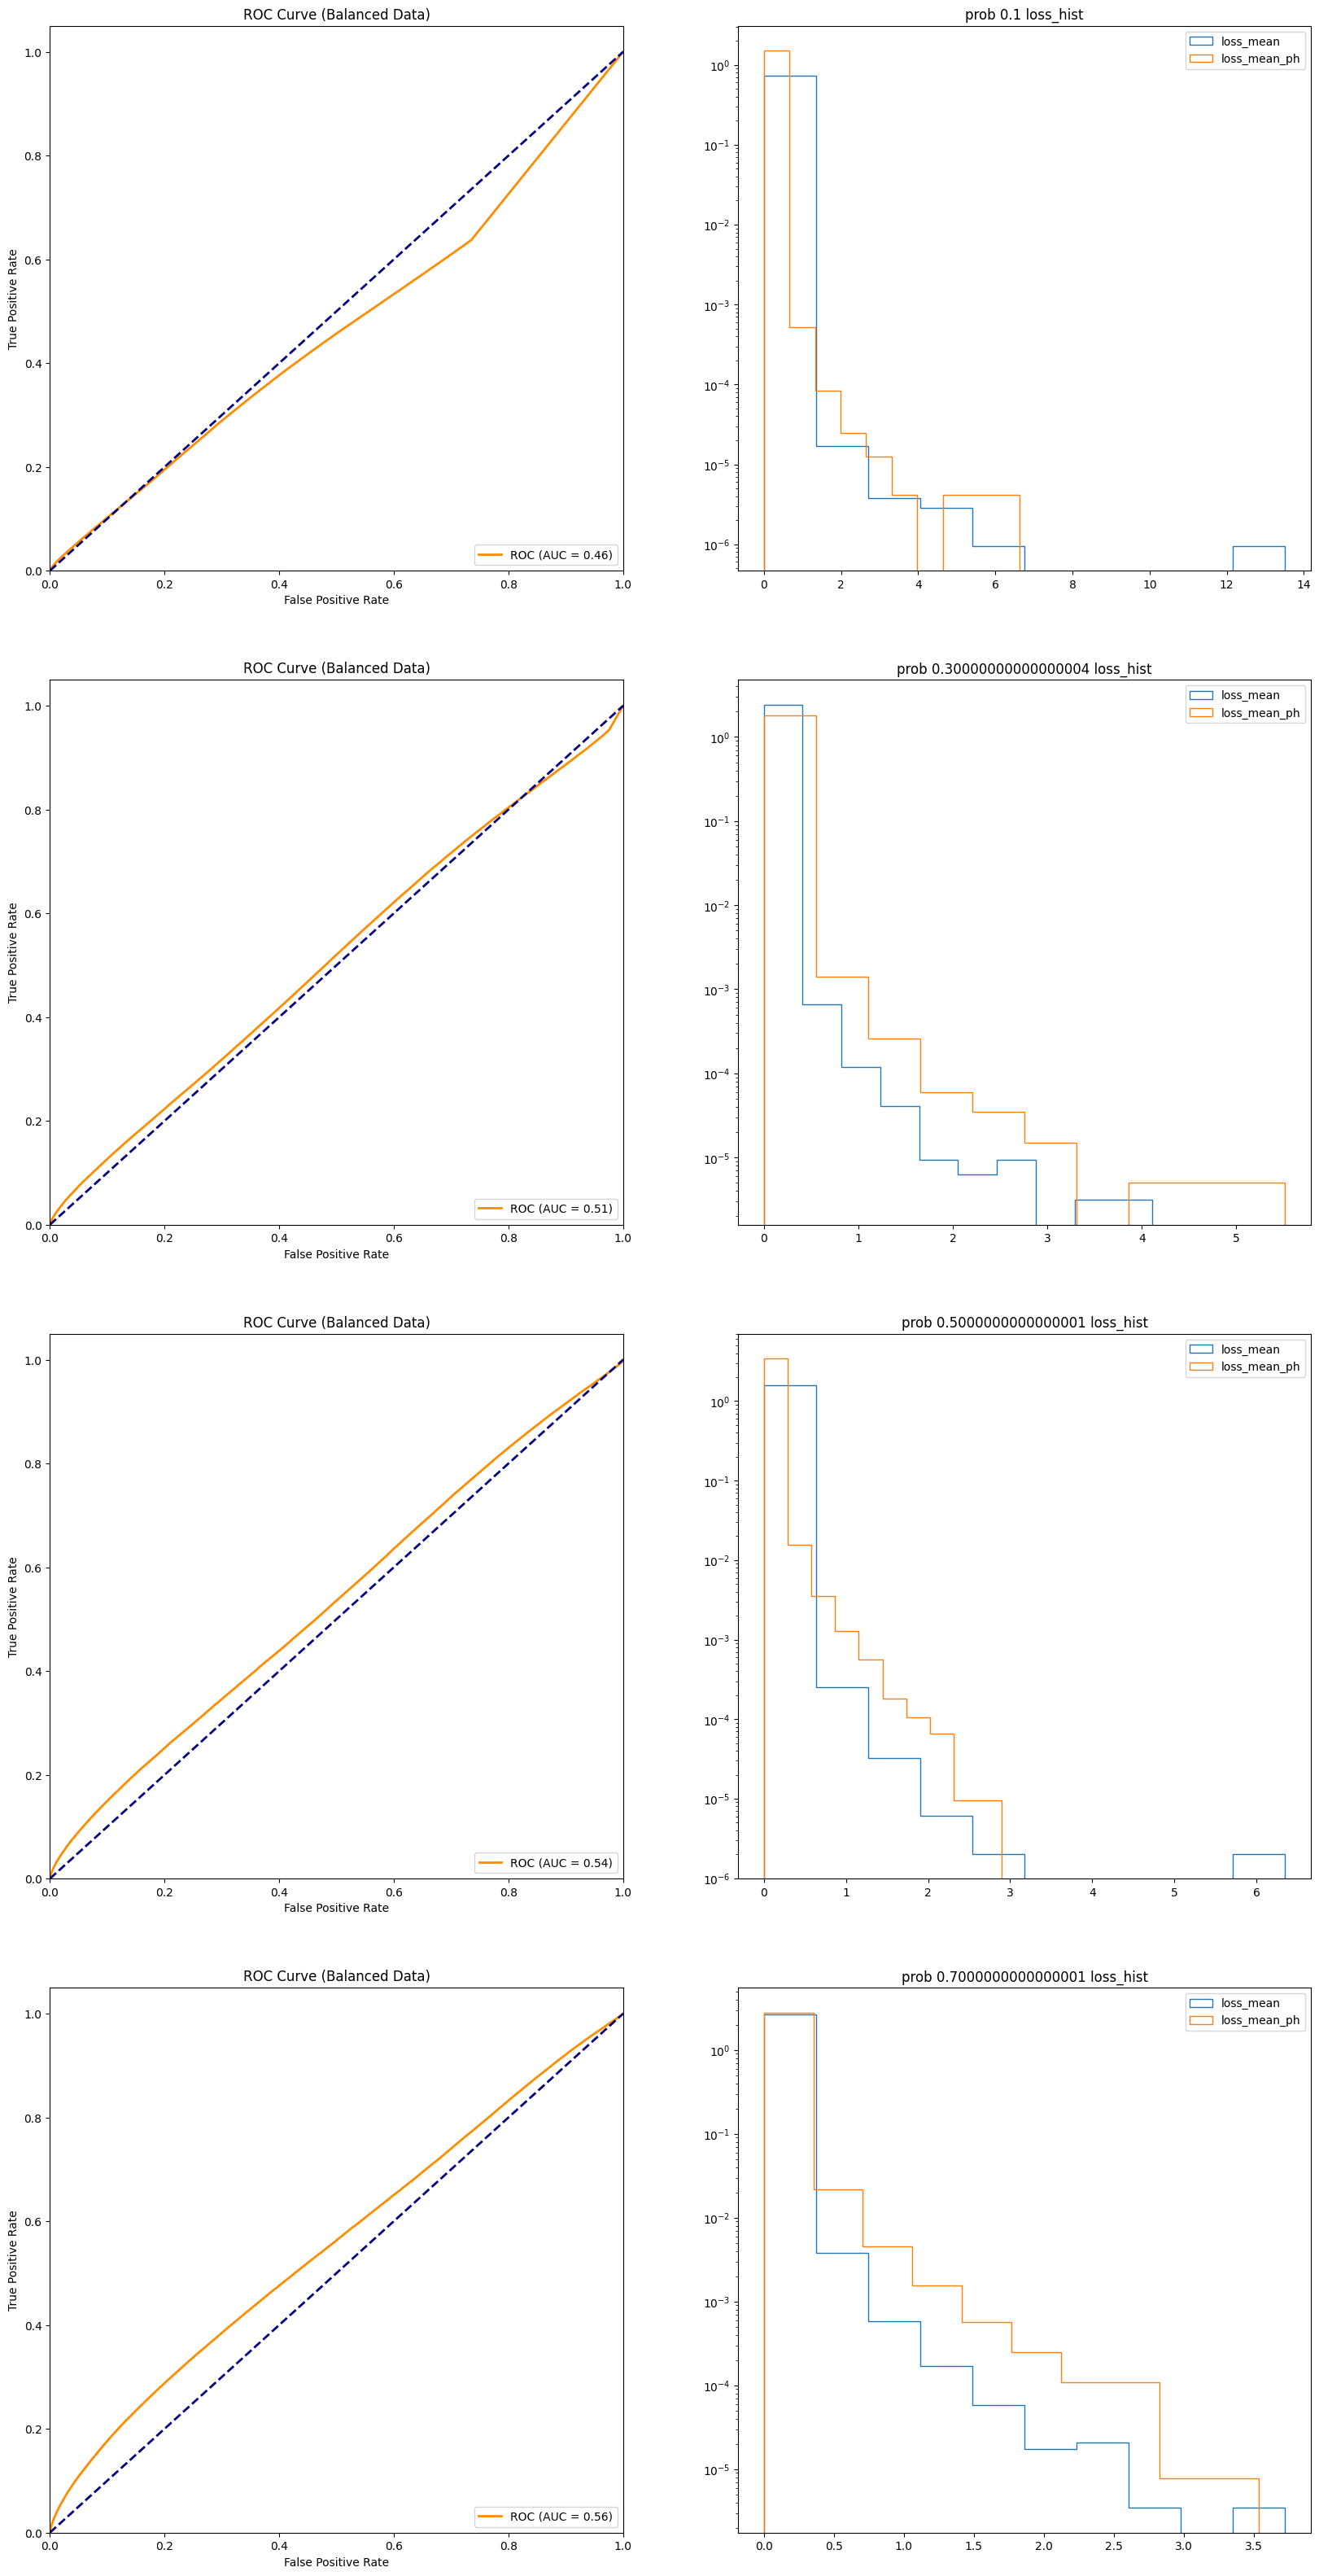

In [66]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
fig,ax = plt.subplots(4,2, figsize=(2*10, 4*10))
for i, pr in enumerate(np.arange(0.1,0.9,0.2)):
    print(pr)
    loss_mean_one_work, index_all_one_work = validation_step(-1, pipline.val_loaders[0], 'pr', probability=pr)
    loss_mean_ph_one_work, index_all_ph_one_work = validation_step(-1, pipline.val_loaders[1], '_ph', probability=pr)
    ax[i][1].hist(loss_mean_one_work, label= 'loss_mean', histtype = 'step',  log=True, density=True)
    ax[i][1].hist(loss_mean_ph_one_work, label = 'loss_mean_ph', histtype = 'step',  log=True, density=True)
    ax[i][1].set_title(f"prob {pr} loss_hist")
    ax[i][1].legend()



    y_scores = np.concatenate([loss_mean_one_work, loss_mean_ph_one_work])  # Объединенные оценки
    y_scores = sigmoid(y_scores)
    y_true = np.concatenate([np.zeros_like(loss_mean_one_work), np.ones_like(loss_mean_ph_one_work)])  # Метки [0, 1]

    # Построение ROC-кривой
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    ax[i][0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    ax[i][0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[i][0].set_xlim([0.0, 1.0])
    ax[i][0].set_ylim([0.0, 1.05])
    ax[i][0].set_xlabel('False Positive Rate')
    ax[i][0].set_ylabel('True Positive Rate')
    ax[i][0].set_title('ROC Curve (Balanced Data)')
    ax[i][0].legend(loc="lower right")
plt.show()

In [53]:
def validation_step(epoch: int, val_loader, particle=None, probability = float(pipline.config['probability'])):
    particle = '' if particle is None else particle
    loss_mean = torch.zeros(0,)
    index_all = torch.zeros(0,)
    pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")
    num_examples = 0
    for x, part, params_CR in pbar_val:  # x should be a batch of sequences with padding
        num_examples += x.size(0)
        with torch.no_grad():
            x_mask, index = random_mask_index(x, probability=probability, mask_v = pipline.config['padding_value'])
            x_mask = x_mask.to(device)
            index_all = torch.concat((index_all, index))
            x = x.to(device)
            part = torch.where(part == 1, 0, 1).to(device) # 0- photon, 1- proton
            params_CR = params_CR.to(device)
            recon_x = pipline.model(x, x_mask)
            loss = Loss.by_ev_return(recon_x, x, x_mask)
            pbar_val.set_description(f"VAL {particle} Loss:")
            loss_mean = torch.concat((loss_mean, loss.to('cpu')))

            # return signal
            # sigqnal = x[:,:,3*4]*x_mask[:,:,3:4]
            
def multy_run(num_runs:int, epoch: int, val_loader, particle=None, probability = float(pipline.config['probability'])):
    particle = '' if particle is None else particle
    loss_mean = torch.zeros(0,)
    index_all = torch.zeros(0,)
    pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")
    num_examples = 0
    for x, part, params_CR in pbar_val:  # x should be a batch of sequences with padding
        num_examples += x.size(0)
        loss_mylty = torch.zeros(0,)
        for i in range(num_runs):
            with torch.no_grad():
                x_mask, index = random_mask_index(x, probability=probability, mask_v = pipline.config['padding_value'])
                x_mask = x_mask.to(device)
                # index_all = torch.concat((index_all, index))
                x = x.to(device)
                part = torch.where(part == 1, 0, 1).to(device) # 0- photon, 1- proton
                params_CR = params_CR.to(device)
                recon_x = pipline.model(x, x_mask)
                loss = Loss.by_ev_return(recon_x, x, x_mask)
                loss_mylty = torch.concat((loss_mylty, loss.unsqueeze(0).to('cpu')), dim=0)
        
        loss_mylty = loss_mylty.mean(dim=0)
        pbar_val.set_description(f"VAL {particle} Loss:")
        loss_mean = torch.concat((loss_mean, loss_mylty.to('cpu')))

            # return signal
            # sigqnal = x[:,:,3*4]*x_mask[:,:,3:4]
    return loss_mean, index_all

In [56]:
pr=0.7
loss_mean_one_work, index_all_one_work = multy_run(100, -1, pipline.val_loaders[0], 'pr', probability=pr)
loss_mean_ph_one_work, index_all_ph_one_work = multy_run(100, -1, pipline.val_loaders[1], '_ph', probability=pr)

VAL Epoch 0 in pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)


VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/home/rfit/miniconda3/envs/python39/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


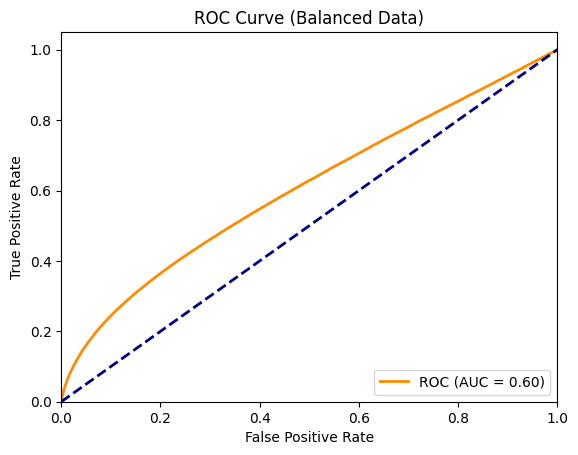

In [57]:

y_scores = np.concatenate([loss_mean_one_work, loss_mean_ph_one_work])  # Объединенные оценки
y_true = np.concatenate([np.zeros_like(loss_mean_one_work), np.ones_like(loss_mean_ph_one_work)])  # Метки [0, 1]

# Разделение на признаки и метки (X должен быть 2D-массивом)
X = y_scores.reshape(-1, 1)  # Используем оценки как единственный признак
y = y_true

# Балансировка и построение ROC
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X, y)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42
)

# Обучаем модель на сбалансированных данных
model = LogisticRegression()
model.fit(X_train, y_train)

# Предсказание вероятностей для теста
y_proba = model.predict_proba(X_test)[:, 1]

# Построение ROC-кривой
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Balanced Data)')
plt.legend(loc="lower right")
plt.show()

Самые большие ошибки

In [67]:
def validation_step_event_return(epoch: int, val_loader, particle=None, probability = float(pipline.config['probability'])):
    particle = '' if particle is None else particle
    loss_mean = torch.zeros(0,)
    index_all = torch.zeros(0,)
    pbar_val = tqdm(val_loader, desc =f"VAL Epoch {epoch + 1} in {particle}, Loss: 0.0")
    recon_list = []
    data_list = []
    mask_list = []
    num_examples = 0
    for x, part, params_CR in pbar_val:  # x should be a batch of sequences with padding
        num_examples += x.size(0)
        with torch.no_grad():
            x_mask, index = random_mask_index(x, probability=probability, mask_v = pipline.config['padding_value'])
            x_mask = x_mask.to(device)
            index_all = torch.concat((index_all, index))
            x = x.to(device)
            part = torch.where(part == 1, 0, 1).to(device) # 0- photon, 1- proton
            params_CR = params_CR.to(device)
            recon_x = pipline.model(x, x_mask)
            loss = Loss.by_ev_return(recon_x, x, x_mask)
            pbar_val.set_description(f"VAL {particle} Loss:")
            loss_mean = torch.concat((loss_mean, loss.to('cpu')))

            recon_list += [i.to('cpu') for i in recon_x]
            data_list += [i.to('cpu') for i in x]
            mask_list += [i.to('cpu') for i in x_mask]
            
    return loss_mean, index_all, data_list, recon_list, mask_list

In [68]:
events_ph = validation_step_event_return(-1, pipline.val_loaders[1], '_ph', probability=0.7)
events_pr = validation_step_event_return(-1, pipline.val_loaders[0], '_pr', probability=0.7)

VAL Epoch 0 in _ph, Loss: 0.0:   0%|          | 0/405 [00:00<?, ?it/s]

/home/rfit/Telescope_Array/phd_work/src/train_VAE/datasets.py:137: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(x), torch.tensor(mc_params[1]), torch.tensor(params_CR)


VAL Epoch 0 in _pr, Loss: 0.0:   0%|          | 0/866 [00:00<?, ?it/s]

In [69]:
def get_lenght(x):
    return len(x) - (x[:,0]==-11).sum()-1-1
def get_most_loss(res, num, pr:str):
    f, axs = plt.subplots(num, 3, figsize = (7*3, 7*num))
    loss_mean, index_all, data_list, recon_list, mask_list = res
    sorted_x, indices = torch.sort(loss_mean)
    for i, ind in enumerate(indices[-num:]):
        names = ['signal', 'flat time', '(real-flat) time']
        ax = axs[i]
        x = data_list[ind]
        recon = recon_list[ind]
        mask = mask_list[ind]
        stop = get_lenght(x)
        for j in range(3,6):
            ax[j-3].plot(x[1:stop+1,j], label = 'real')
            ax[j-3].plot(recon[1:stop+1,j], label = 'fake')
            ax[j-3].plot(recon[1:stop+1,j]*mask[1:stop+1,j], '--', label = 'fake_mask')
            ax[j-3].set_title(loss_mean[ind])
            ax[j-3].legend()
    f.suptitle(f'probability {pr} highest loss', fontweight='bold')

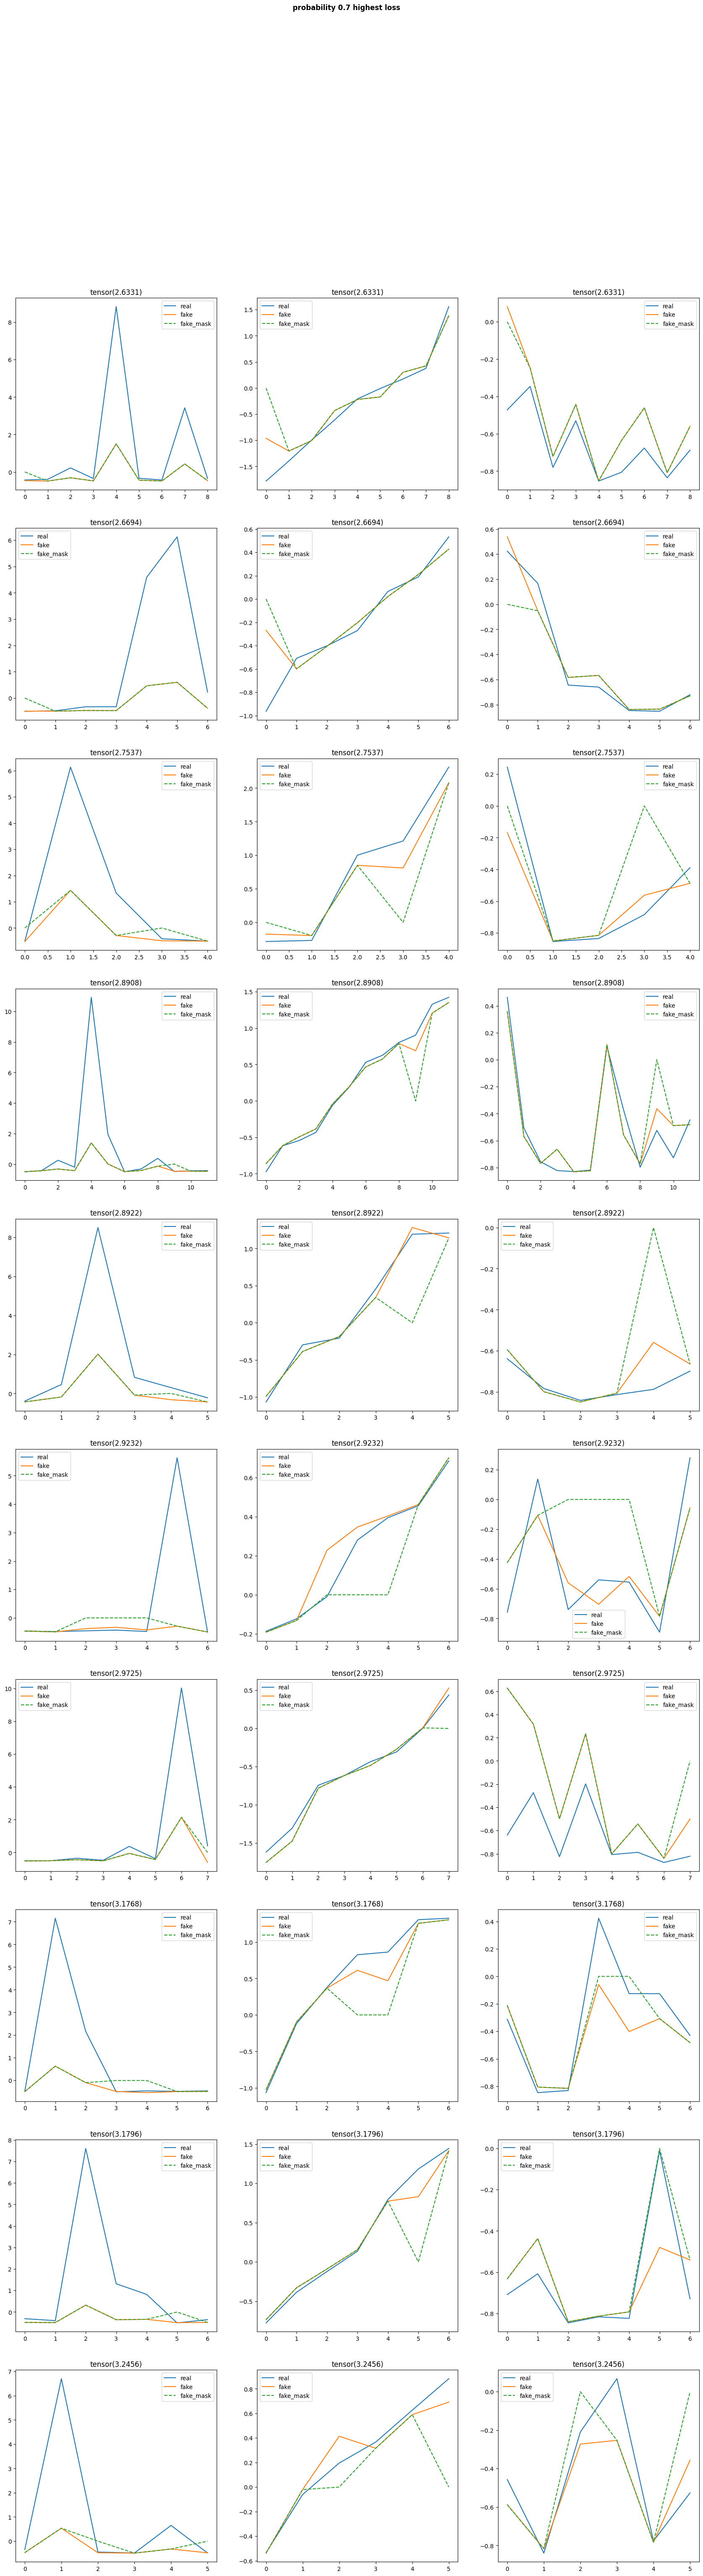

In [71]:
get_most_loss(events_ph, 10, 0.7)

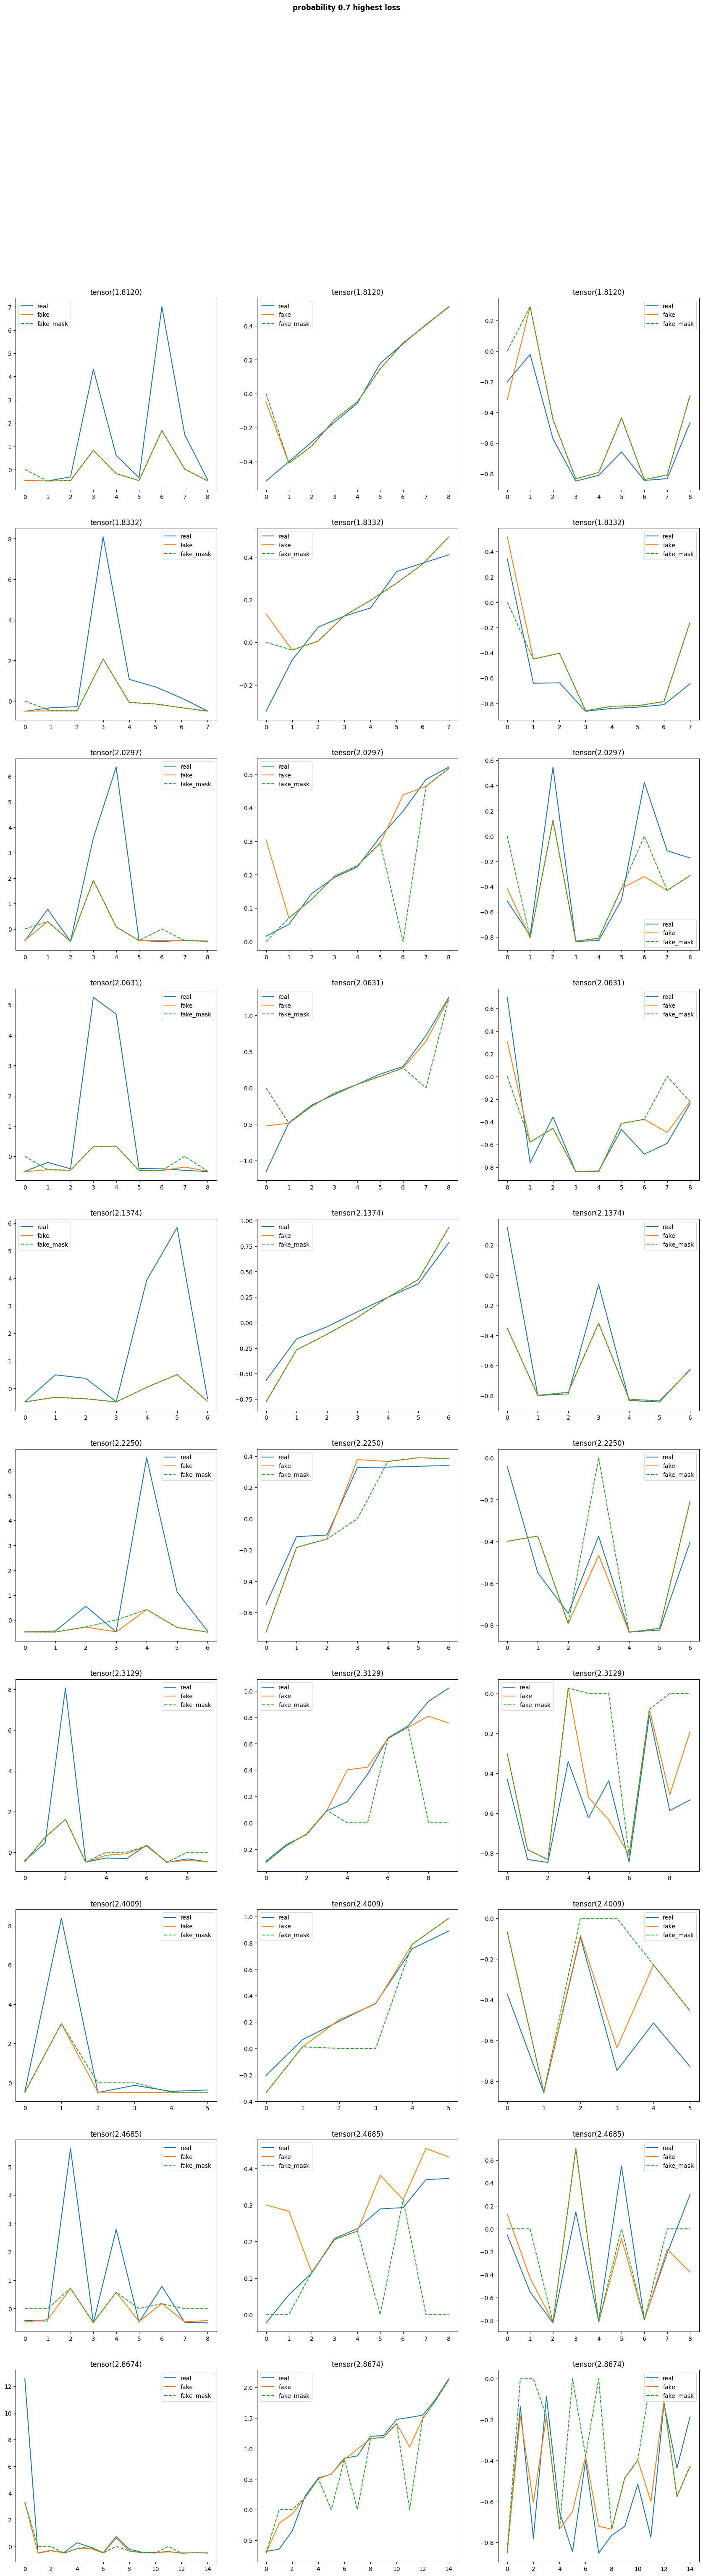

In [72]:
get_most_loss(events_pr, 10, 0.7)